[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Time-Series-Analysis/blob/main/notebooks/EN/chapter9_lecture_notebook.ipynb)

# Time Series Analysis — Chapter 9: Machine learning for time series

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- Forecasting as supervised learning: lags, rolling windows, calendar features; recursive, direct and MIMO strategies.
- Walk-forward validation, leakage, the bias–variance trade-off.
- Ridge and lasso; regression trees, random forest, gradient boosting; trees cannot extrapolate.
- Neural networks: the MLP and a small LSTM (PyTorch, CPU).
- Electricity load of Romania: ML against the statistical models of Chapter 4, MASE and Diebold–Mariano; prediction intervals by quantile boosting and conformal prediction.
- Romanian inflation with local and global models; realised volatility (HAR against ML); the sign of returns.
- Case studies: the M4 competition and Gu, Kelly and Xiu (2020).
- References: Huang and Petukhina (2022), *Applied Time Series Analysis and Forecasting with Python*, Ch. 10; Hyndman and Athanasopoulos, *Forecasting: Principles and Practice* (3rd ed.), Sec. 12.4; Hastie, Tibshirani and Friedman (2009); Makridakis, Spiliotis and Assimakopoulos (2020, 2022).

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/TSA/Chapter_9'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/TSA - Serii de timp/repo/notebooks/EN


In [2]:
import os
os.environ['OMP_NUM_THREADS'] = '1'   # small data: one thread per model fit is faster
# PyTorch is preinstalled in Google Colab; it is needed only for the LSTM

In [3]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [4]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import tsa_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the TSA repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [5]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the TSA repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Definitions and helpers used in the whole notebook

- `load_daily()`: daily mean load of Romania in GW (ENTSO-E, the file of Chapter 4), 2022–2026.
- `calendar(idx)`: weekday dummies, annual Fourier terms, Orthodox Easter, Christmas, public holidays.
- `direct_frame(y, h)`: the supervised table for horizon $h$ (14 lags, 7- and 28-day means, the same weekday, the calendar of the target day; target $y_{t+h}$).
- `forecast_direct`, `forecast_recursive`, `forecast_mlp`, `forecast_lstm`: the four multi-step strategies.
- `dm_raw(l1, l2)`: Diebold–Mariano test with the Harvey–Leybourne–Newbold correction (Chapter 4).

In [6]:
import math
from matplotlib.patches import Rectangle, Circle, FancyArrowPatch
from sklearn.ensemble import (HistGradientBoostingClassifier, HistGradientBoostingRegressor, RandomForestClassifier, RandomForestRegressor)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LassoCV, LinearRegression, LogisticRegression, RidgeCV, lasso_path
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold, TimeSeriesSplit
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor, plot_tree
from dateutil.easter import easter, EASTER_ORTHODOX
HERE = "."
SEED = 2026
# daily load: the file and the evaluation design of Chapter 4 (26 origins, every 14 days, horizon 14 days)
LOAD_FILE = 'ch4_ro_load_hourly.csv'
LOAD_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/Quantlets/Ch_04/'
LOAD_END = '2026-06-30'
CV_FIRST, CV_STEP, CV_H = '2025-06-30', 14, 14
LAGS = 14                      # y_t, ..., y_{t-13} at the forecast origin
HICP = ('prc_hicp_minr', 'M.I15.TOTAL.{}')
EU27 = ['AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'EL', 'ES', 'FI', 'FR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV',
        'MT', 'NL', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK']
INF_START, INF_OOS = '2005-01-01', 2016          # inflation targeting in Romania since August 2005; tests from 2016
INF_H = [1, 3, 6, 12]
RV_H = 5                                          # volatility target: mean variance proxy over the next 5 days
RV_OOS = {'sp500': '2013-01-01', 'dax': '2013-01-01'}
OHLC_START = {'sp500': '2008-01-01', 'dax': '2008-01-01'}
HAR = ['d', 'w', 'm']
EXT = HAR + ['d1', 'd2', 'd3', 'd4', 'q', 'r', 'r_neg', 'abs_r']
SIGN_FEATS = ['r0', 'r1', 'r2', 'r3', 'r4', 'm5', 'm21', 'm63', 'v21', 'v63']
NAME = {'sp500': 'S&P 500', 'dax': 'DAX', 'bet': 'BET'}
MCOL = {'Seasonal naive': st.Amber, 'ETS': st.Teal, 'SARIMA': st.Purple, 'DHR': st.MainBlue, 'Combination': st.Crimson,
        'Ridge': st.Teal, 'RF': st.Forest, 'GB direct': st.IDAred, 'GB recursive': st.Orange, 'MLP': '#6B8E23',
        'LSTM': st.Purple, 'RW': st.Amber, 'AR': st.MainBlue, 'Lasso': st.Teal, 'GB local': st.IDAred,
        'GB global': st.Orange, 'HAR': st.MainBlue, 'GB': st.IDAred, 'Mean': st.Amber, 'Logit': st.MainBlue}
GB_PARAMS = dict(max_iter=300, learning_rate=0.05, max_leaf_nodes=15, min_samples_leaf=20, l2_regularization=1.0)
FEATS = ['lag0', 'lag1', 'lag2', 'lag3', 'lag4', 'lag5', 'lag6', 'lag7', 'lag8', 'lag9', 'lag10', 'lag11', 'lag12', 'lag13', 'mean7', 'mean28', 'same_dow', 'mon', 'tue', 'wed', 'thu', 'fri', 'sat', 'sin1', 'cos1', 'sin2', 'cos2', 'easter', 'xmas', 'holiday']
INF_FEATS = ['pi0', 'pi1', 'pi2', 'pi3', 'pi6', 'pi12', 'm0', 'm1', 'm2', 'm3s', 'm6s', 'month']
M4_FILE = 'ch9_m4_owa.csv'
HIGHLIGHT = {'lag0': st.MainBlue, 'same_dow': st.IDAred, 'mean7': st.Forest, 'sat': st.Orange, 'holiday': st.Purple, 'easter': st.Amber, 'xmas': st.Teal}
M4_TYPES = {'Statistical': st.MainBlue, 'Combination (S)': st.Teal, 'Combination (S & ML)': st.Purple, 'Combination (ML)': st.Orange, 'Machine Learning': st.IDAred, 'Hybrid': st.Forest, 'Other': st.Amber}
GKX_MODELS = ['OLS-3+H', 'PLS', 'PCR', 'ENet+H', 'GLM+H', 'RF', 'GBRT+H', 'NN1', 'NN2', 'NN3', 'NN4', 'NN5']
GKX_R2 = [0.16, 0.27, 0.26, 0.11, 0.19, 0.33, 0.34, 0.33, 0.39, 0.4, 0.39, 0.36]
GKX_SR = [0.61, 0.72, 0.88, 0.39, 0.76, 0.98, 0.81, 1.17, 1.16, 1.2, 1.35, 1.15]


def ro_holidays(years):
    """Romanian public holidays (Orthodox Easter and Pentecost from dateutil): date -> name (as in Chapter 4)."""
    out = {}
    for y in years:
        e = pd.Timestamp(easter(y, EASTER_ORTHODOX))
        day = pd.Timedelta(days=1)
        hol = {'New Year': [f'{y}-01-01', f'{y}-01-02'], 'Union Day': [f'{y}-01-24'],
               'Easter': [e - 2 * day, e, e + day], 'Labour Day': [f'{y}-05-01'], "Children's Day": [f'{y}-06-01'],
               'Pentecost': [e + 49 * day, e + 50 * day], 'Assumption': [f'{y}-08-15'], "St Andrew's Day": [f'{y}-11-30'],
               'National Day': [f'{y}-12-01'], 'Christmas': [f'{y}-12-25', f'{y}-12-26']}
        if y >= 2024:
            hol['Epiphany'] = [f'{y}-01-06', f'{y}-01-07']
        for k, v in hol.items():
            for x in v:
                out[pd.Timestamp(x)] = k
    return pd.Series(out, name='holiday').sort_index()


def load_daily(end=LOAD_END):
    """Daily mean electricity load of Romania in GW (ENTSO-E hourly values, Chapter 4 extract, Romanian winter time;
    isolated one-hour glitches and missing hours interpolated), 1 January 2022 - 30 June 2026."""
    local = [os.path.join(HERE, '..', 'Ch_04', LOAD_FILE)] + [os.path.join(d, 'Quantlets', 'Ch_04', LOAD_FILE)
                                                              for d in ('.', '..', '../..', '../../..')]
    src = next((p for p in local if os.path.exists(p)), LOAD_RAW + LOAD_FILE)
    s = pd.read_csv(src, index_col=0, parse_dates=True).iloc[:, 0]
    s = s.loc[:pd.Timestamp(end) + pd.Timedelta(hours=21)]
    s.index = s.index + pd.Timedelta(hours=2)
    s = s.reindex(pd.date_range(s.index[0], s.index[-1], freq='h'))
    r = s / ((s.shift(1) + s.shift(-1)) / 2)
    s[(r < 0.7) | (r > 1.3)] = np.nan
    d = s.interpolate().resample('D').mean() / 1000
    return d.loc['2022-01-01':end].rename('load')


def calendar(idx):
    """Calendar features of the dates idx: weekday dummies (Sunday is the base), two annual Fourier pairs, Orthodox
    Easter (Friday to Monday), the Christmas - New Year days (24 December - 2 January) and other public holidays."""
    idx = pd.DatetimeIndex(idx)
    X = pd.DataFrame(index=idx)
    for j, nm in enumerate(['mon', 'tue', 'wed', 'thu', 'fri', 'sat']):
        X[nm] = (idx.dayofweek == j).astype(float)
    doy = idx.dayofyear.values
    for k in (1, 2):
        X[f'sin{k}'] = np.sin(2 * np.pi * k * doy / 365.25)
        X[f'cos{k}'] = np.cos(2 * np.pi * k * doy / 365.25)
    hol = ro_holidays(range(idx[0].year, idx[-1].year + 1)).reindex(idx)
    X['easter'] = (hol == 'Easter').astype(float).values
    X['xmas'] = (((idx.month == 12) & (idx.day >= 24)) | ((idx.month == 1) & (idx.day <= 2))).astype(float)
    X['holiday'] = (hol.notna().values & (X['easter'] == 0).values & (X['xmas'] == 0).values).astype(float)
    return X


def direct_frame(y, h):
    """Supervised table for horizon h: one row per forecast origin t. Features known at t: y_t, ..., y_{t-13}, the
    7- and 28-day means, the last value of the same weekday as the target (y_{t+h-7k}, k = ceil(h/7)) and the calendar
    of the target day t+h. Target: y_{t+h}."""
    X = pd.DataFrame({f'lag{j}': y.shift(j) for j in range(LAGS)}, index=y.index)
    X['mean7'] = y.rolling(7).mean()
    X['mean28'] = y.rolling(28).mean()
    k = math.ceil(h / 7)
    X['same_dow'] = y.shift(7 * k - h)
    cal = calendar(y.index + pd.Timedelta(days=h))
    cal.index = y.index
    X = pd.concat([X, cal], axis=1)
    X['y'] = y.shift(-h)
    return X.iloc[27:]


def origins(y=None, first=CV_FIRST, step=CV_STEP, h=CV_H):
    """The forecast origins of Chapter 4: every 14 days from 30 June 2025, while 14 days of data remain."""
    y = load_daily() if y is None else y
    return list(pd.date_range(first, y.index[-1] - pd.Timedelta(days=h), freq=f'{step}D'))


def oos_r2(y, yhat, ybar):
    """Out-of-sample R^2 against a benchmark forecast ybar: 1 - sum (y - yhat)^2 / sum (y - ybar)^2."""
    y, yhat, ybar = (np.asarray(a, float) for a in (y, yhat, ybar))
    return float(1 - np.sum((y - yhat) ** 2) / np.sum((y - ybar) ** 2))


def dm_raw(l1, l2, h=1):
    """Diebold-Mariano test on two loss series (Chapter 4): HLN small-sample correction, t(n - 1) p-value.
    d_t = l1_t - l2_t: a negative mean favours the first forecast."""
    d = np.asarray(l1, float) - np.asarray(l2, float)
    n = len(d)
    dbar = d.mean()
    g = [np.mean((d[k:] - dbar) * (d[:n - k] - dbar)) for k in range(h)]
    v = (g[0] + 2 * sum(g[1:])) / n
    dm = dbar / np.sqrt(v)
    hln = np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n) * dm
    return {'dbar': float(dbar), 'dm': float(dm), 'hln': float(hln), 'p': float(2 * stats.t.sf(abs(hln), n - 1)), 'n': int(n)}


def make_ridge():
    return make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 13), cv=TimeSeriesSplit(5)))


def make_rf(seed=SEED, n=200):
    return RandomForestRegressor(n_estimators=n, min_samples_leaf=3, max_features=0.5, n_jobs=-1, random_state=seed)


def make_gb(seed=SEED, **kw):
    return HistGradientBoostingRegressor(random_state=seed, **{**GB_PARAMS, **kw})


def direct_models():
    """The direct-strategy learners: ridge, random forest, gradient boosting."""
    return {'Ridge': make_ridge, 'RF': make_rf, 'GB direct': make_gb}


def forecast_direct(y, origin, make, h_max=CV_H, frames=None, feats=None):
    """Direct strategy: one model per horizon h = 1..h_max, trained on the origins t with t + h <= origin."""
    feats = feats or FEATS
    out = []
    for h in range(1, h_max + 1):
        F = frames[h] if frames else direct_frame(y, h)
        tr = F.loc[:origin - pd.Timedelta(days=h)].dropna()
        m = make().fit(tr[feats].values, tr['y'].values)
        out.append(float(m.predict(F.loc[[origin], feats].values)[0]))
    return np.array(out)


def forecast_recursive(y, origin, make, h_max=CV_H):
    """Recursive strategy: one one-step model; its forecast replaces the unknown value and the step is repeated."""
    F = direct_frame(y.loc[:origin], 1)
    tr = F.dropna()
    m = make().fit(tr[FEATS].values, tr['y'].values)
    ext = y.loc[:origin].copy()
    out = []
    for h in range(1, h_max + 1):
        row = direct_frame(ext.iloc[-40:], 1).iloc[[-1]]
        f = float(m.predict(row[FEATS].values)[0])
        out.append(f)
        ext.loc[ext.index[-1] + pd.Timedelta(days=1)] = f
    return np.array(out)


def mimo_inputs(y, t, window=28, h_max=CV_H):
    """Multi-output (MIMO) inputs at origin t: the last `window` values, the weekday of t (one-hot) and the
    holiday flags of the next h_max days."""
    past = y.loc[:t].values[-window:]
    dow = np.eye(7)[t.dayofweek]
    cal = calendar(pd.date_range(t + pd.Timedelta(days=1), periods=h_max, freq='D'))
    hol = (cal[['easter', 'xmas', 'holiday']].sum(axis=1) > 0).astype(float).values
    return np.concatenate([past, dow, hol])


class MLPMulti:
    """Average of three small MLPs with 14 outputs (one per horizon); inputs and targets standardised."""

    def __init__(self, hidden=(32,), alpha=1e-2, n_models=3, epochs=500, seed=SEED):
        self.hidden, self.alpha, self.n_models, self.epochs, self.seed = hidden, alpha, n_models, epochs, seed

    def fit(self, X, Y):
        self.sx = StandardScaler().fit(X)
        self.my, self.sy = Y.mean(), Y.std()
        Z, T = self.sx.transform(X), (Y - self.my) / self.sy
        self.models = [MLPRegressor(hidden_layer_sizes=self.hidden, alpha=self.alpha, max_iter=self.epochs,
                                    early_stopping=False, random_state=self.seed + i).fit(Z, T)
                       for i in range(self.n_models)]
        return self

    def predict(self, X):
        Z = self.sx.transform(X)
        return self.my + self.sy * np.mean([m.predict(Z) for m in self.models], axis=0)


def forecast_mlp(y, origin, h_max=CV_H, window=28, seed=SEED):
    """MIMO strategy: one MLP gives the 14 forecasts at once."""
    yy = y.loc[:origin]
    ts = yy.index[window + 1:len(yy) - h_max]
    X = np.array([mimo_inputs(yy, t, window, h_max) for t in ts])
    Y = np.array([yy.loc[t + pd.Timedelta(days=1):t + pd.Timedelta(days=h_max)].values for t in ts])
    m = MLPMulti(seed=seed).fit(X, Y)
    return m.predict(mimo_inputs(yy, origin, window, h_max)[None, :])[0]


def forecast_lstm(y, origin, h_max=CV_H, window=56, hidden=32, epochs=150, seed=SEED):
    """A small LSTM (PyTorch, CPU): input = the last 56 days of standardised load and weekday dummies, one layer of 32
    units, a linear layer with 14 outputs (MIMO); full-batch Adam, fixed seed."""
    import torch
    torch.manual_seed(seed)
    torch.set_num_threads(1)
    yy = y.loc[:origin]
    mu, sd = yy.mean(), yy.std()
    z = ((yy - mu) / sd).values
    dow = np.eye(7)[yy.index.dayofweek]
    seq = np.column_stack([z, dow]).astype(np.float32)
    idx = range(window, len(z) - h_max + 1)
    X = np.stack([seq[i - window:i] for i in idx])
    Y = np.stack([z[i:i + h_max] for i in idx]).astype(np.float32)

    class Net(torch.nn.Module):
        def __init__(self):
            super().__init__()
            self.lstm = torch.nn.LSTM(seq.shape[1], hidden, batch_first=True)
            self.out = torch.nn.Linear(hidden, h_max)

        def forward(self, x):
            o, _ = self.lstm(x)
            return self.out(o[:, -1])

    net = Net()
    opt = torch.optim.Adam(net.parameters(), lr=0.01)
    Xt, Yt = torch.tensor(X), torch.tensor(Y)
    losses = []
    for _ in range(epochs):
        opt.zero_grad()
        loss = torch.mean((net(Xt) - Yt) ** 2)
        loss.backward()
        opt.step()
        losses.append(float(loss))
    with torch.no_grad():
        f = net(torch.tensor(seq[None, -window:])).numpy()[0]
    return mu + sd * f, losses

## 1. From a series to a table

- The load, three features, a small lag table and the three multi-step strategies.

         date  dow         y
0  2025-06-21    5  5.210740
1  2025-06-22    6  4.726250
2  2025-06-23    0  5.803823
3  2025-06-24    1  6.031896
4  2025-06-25    2  6.380094
5  2025-06-26    3  6.613437
6  2025-06-27    4  6.593896
7  2025-06-28    5  5.776594
8  2025-06-29    6  5.092688


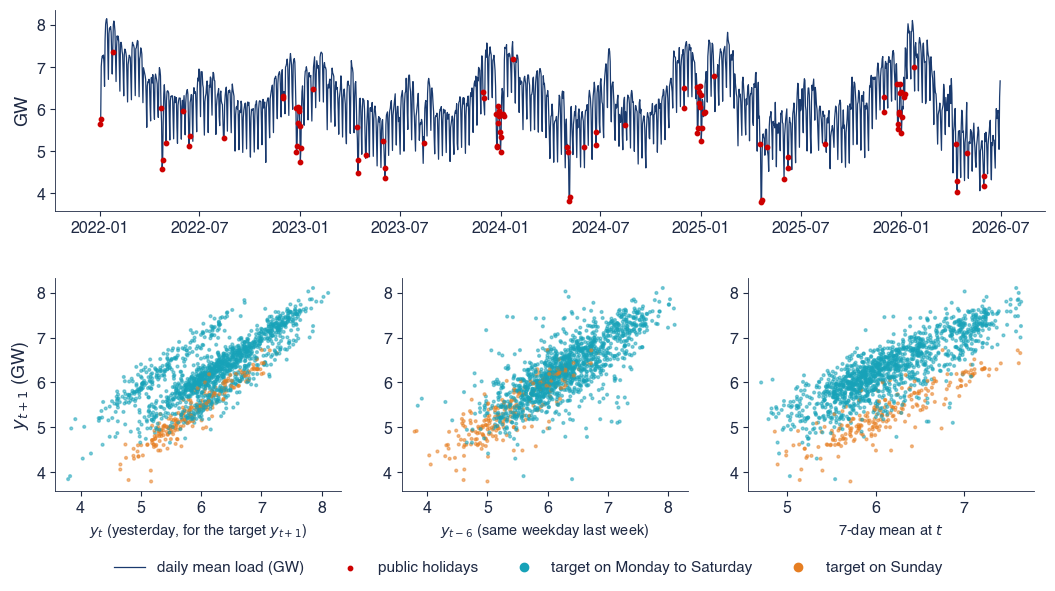

{'n': 1642, 'first': '2022-01-01', 'last': '2026-06-30', 'mean': 6.176605819163391, 'min': 3.7942291666666663, 'min_d': '2025-04-20', 'max': 8.148552083333334, 'max_d': '2022-01-13', 'corr': {'lag0': 0.7654451376731719, 'lag6': 0.8152223193005614, 'mean7': 0.7412723428400797}, 'rows': 1614, 'n_feats': 30}


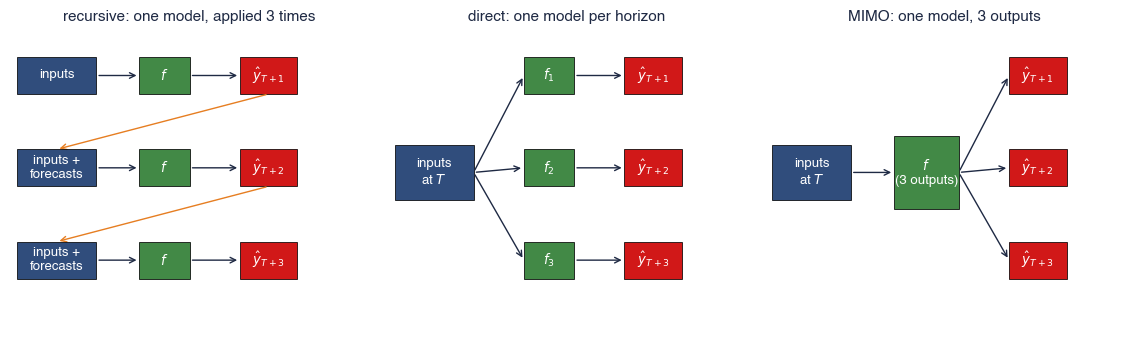

,lag0,lag1,lag2,lag3,lag4,lag5,lag6,lag7,lag8,lag9,...,fri,sat,sin1,cos1,sin2,cos2,easter,xmas,holiday,y
2022-01-28,7.855739,8.009896,8.093091,8.010719,7.368104,6.834167,7.312146,7.831458,7.962135,7.902750,...,0.0,1.0,0.478434,0.878124,0.840248,0.542202,0.0,0.0,0.0,7.257812
2022-01-29,7.257812,7.855739,8.009896,8.093091,8.010719,7.368104,6.834167,7.312146,7.831458,7.962135,...,0.0,0.0,0.493468,0.869764,0.858402,0.512978,0.0,0.0,0.0,6.655719
2022-01-30,6.655719,7.257812,7.855739,8.009896,8.093091,8.010719,7.368104,6.834167,7.312146,7.831458,...,0.0,0.0,0.508356,0.861147,0.875539,0.483147,0.0,0.0,0.0,7.479635
2022-01-31,7.479635,6.655719,7.257812,7.855739,8.009896,8.093091,8.010719,7.368104,6.834167,7.312146,...,0.0,0.0,0.523094,0.852275,0.891640,0.452745,0.0,0.0,0.0,7.740646
2022-02-01,7.740646,7.479635,6.655719,7.257812,7.855739,8.009896,8.093091,8.010719,7.368104,6.834167,...,0.0,0.0,0.537677,0.843151,0.906686,0.421806,0.0,0.0,0.0,7.650271


In [7]:
def mini_table(y=None, end='2025-06-29', n=9):
    """The last n days before a date as a small supervised table: weekday, y_t, y_{t-1}, y_{t-2} and the target."""
    y = load_daily() if y is None else y
    s = y.loc[:end].iloc[-n:]
    rows = [{'date': str(d.date()), 'dow': int(d.dayofweek), 'y': float(v)} for d, v in s.items()]
    return {'rows': rows, 'mean': float(s.mean())}


def fig_features(y=None, save=True):
    """Top: daily load 2022-2026; bottom: the target against three features (y_{t-1}, y_{t-7}, the 7-day mean)."""
    y = load_daily() if y is None else y
    F = direct_frame(y, 1).dropna()
    fig = plt.figure(figsize=(11, 5.6))
    ax0 = fig.add_axes([0.07, 0.6, 0.9, 0.36])
    ax0.plot(y.index, y.values, color=st.MainBlue, lw=0.9, label='daily mean load (GW)')
    hol = calendar(y.index)
    m = (hol['easter'] + hol['xmas'] + hol['holiday']) > 0
    ax0.scatter(y.index[m], y.values[m], s=10, color=st.IDAred, zorder=3, label='public holidays')
    ax0.set_ylabel('GW')
    cols = [('lag0', '$y_{t}$ (yesterday, for the target $y_{t+1}$)'), ('lag6', '$y_{t-6}$ (same weekday last week)'),
            ('mean7', '7-day mean at $t$')]
    corr = {}
    for i, (c, lab) in enumerate(cols):
        ax = fig.add_axes([0.07 + i * 0.315, 0.1, 0.26, 0.38])
        wk = F['sat'] + F['mon'] + F['tue'] + F['wed'] + F['thu'] + F['fri']
        ax.scatter(F[c], F['y'], s=4, alpha=0.5, color=np.where(wk.values > 0, st.Teal, st.Orange))
        ax.set_xlabel(lab, fontsize=10.5)
        if i == 0:
            ax.set_ylabel('$y_{t+1}$ (GW)')
        corr[c] = float(np.corrcoef(F[c], F['y'])[0, 1])
    h1 = plt.Line2D([], [], marker='o', ls='', color=st.Teal, label='target on Monday to Saturday')
    h2 = plt.Line2D([], [], marker='o', ls='', color=st.Orange, label='target on Sunday')
    hh, ll = ax0.get_legend_handles_labels()
    fig.legend(hh + [h1, h2], ll + [h1.get_label(), h2.get_label()], loc='upper center', bbox_to_anchor=(0.5, 0.0),
               ncol=4, frameon=False)
    st.check_no_grey(fig)
    if save:
        st.save_fig('tsa_ch9_features')
    else:
        plt.show()
    return {'n': int(len(y)), 'first': str(y.index[0].date()), 'last': str(y.index[-1].date()), 'mean': float(y.mean()),
            'min': float(y.min()), 'min_d': str(y.idxmin().date()), 'max': float(y.max()), 'max_d': str(y.idxmax().date()),
            'corr': corr, 'rows': int(len(F)), 'n_feats': len(FEATS)}


def fig_strategies(save=True):
    """Diagram of the recursive, direct and multi-output (MIMO) strategies for a 3-step forecast."""
    fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.6))
    titles = ['recursive: one model, applied 3 times', 'direct: one model per horizon', 'MIMO: one model, 3 outputs']
    for a, ttl in zip(axes, titles):
        a.set_xlim(0, 10)
        a.set_ylim(0, 6.6)
        a.axis('off')
        a.set_title(ttl, fontsize=11)

    def box(a, x, y, txt, col, w=1.6, hgt=0.8):
        a.add_patch(Rectangle((x, y), w, hgt, facecolor=col, edgecolor='black', lw=0.6, alpha=0.9))
        a.text(x + w / 2, y + hgt / 2, txt, ha='center', va='center', fontsize=9.5, color='white')

    def arrow(a, p, q, col=st.DarkText):
        a.add_patch(FancyArrowPatch(p, q, arrowstyle='->', mutation_scale=10, color=col, lw=1))

    # recursive
    a = axes[0]
    for i in range(3):
        y0 = 5.2 - 2.0 * i
        box(a, 0.2, y0, 'inputs' if i == 0 else 'inputs +\nforecasts', st.MainBlue, w=2.2)
        box(a, 3.6, y0, '$f$', st.Forest, w=1.4)
        box(a, 6.4, y0, f'$\\hat y_{{T+{i + 1}}}$', st.IDAred, w=1.6)
        arrow(a, (2.4, y0 + 0.4), (3.6, y0 + 0.4))
        arrow(a, (5.0, y0 + 0.4), (6.4, y0 + 0.4))
        if i < 2:
            arrow(a, (7.2, y0), (1.3, y0 - 1.2), st.Orange)
    # direct
    a = axes[1]
    box(a, 0.2, 2.9, 'inputs\nat $T$', st.MainBlue, w=2.2, hgt=1.2)
    for i in range(3):
        y0 = 5.2 - 2.0 * i
        box(a, 3.8, y0, f'$f_{i + 1}$', st.Forest, w=1.4)
        box(a, 6.6, y0, f'$\\hat y_{{T+{i + 1}}}$', st.IDAred, w=1.6)
        arrow(a, (2.4, 3.5), (3.8, y0 + 0.4))
        arrow(a, (5.2, y0 + 0.4), (6.6, y0 + 0.4))
    # MIMO
    a = axes[2]
    box(a, 0.2, 2.9, 'inputs\nat $T$', st.MainBlue, w=2.2, hgt=1.2)
    box(a, 3.6, 2.7, '$f$\n(3 outputs)', st.Forest, w=1.8, hgt=1.6)
    for i in range(3):
        y0 = 5.2 - 2.0 * i
        box(a, 6.8, y0, f'$\\hat y_{{T+{i + 1}}}$', st.IDAred, w=1.6)
        arrow(a, (5.4, 3.5), (6.8, y0 + 0.4))
    arrow(axes[2], (2.4, 3.5), (3.6, 3.5))
    st.check_no_grey(fig)
    fig.tight_layout()
    if save:
        st.save_fig('tsa_ch9_strategies')
    else:
        plt.show()


y = load_daily()
print(pd.DataFrame(mini_table(y)['rows']))
print(fig_features(y, save=False))
fig_strategies(save=False)
F = direct_frame(y, 1)
F.dropna().head()

## 2. Validation without leakage

- Four validation schemes; random folds on overlapping targets; bias and variance of trees.

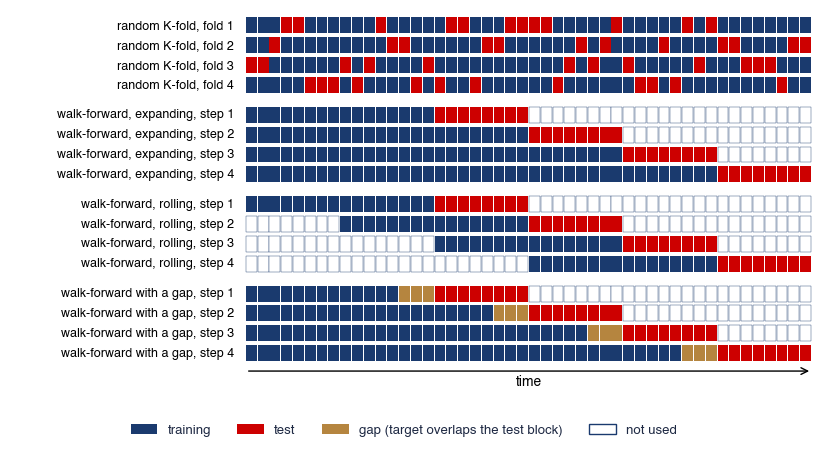

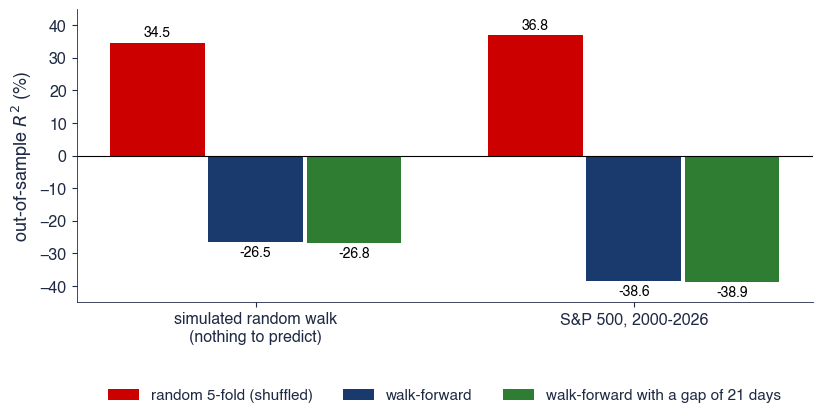

{'sim': {'n': 3917, 'kfold': 0.34537129462104277, 'wf': -0.2645122917920115, 'gap': -0.2683483261015267}, 'sp500': {'n': 6631, 'kfold': 0.36806558296967395, 'wf': -0.3855334217211017, 'gap': -0.3891857210442977}}


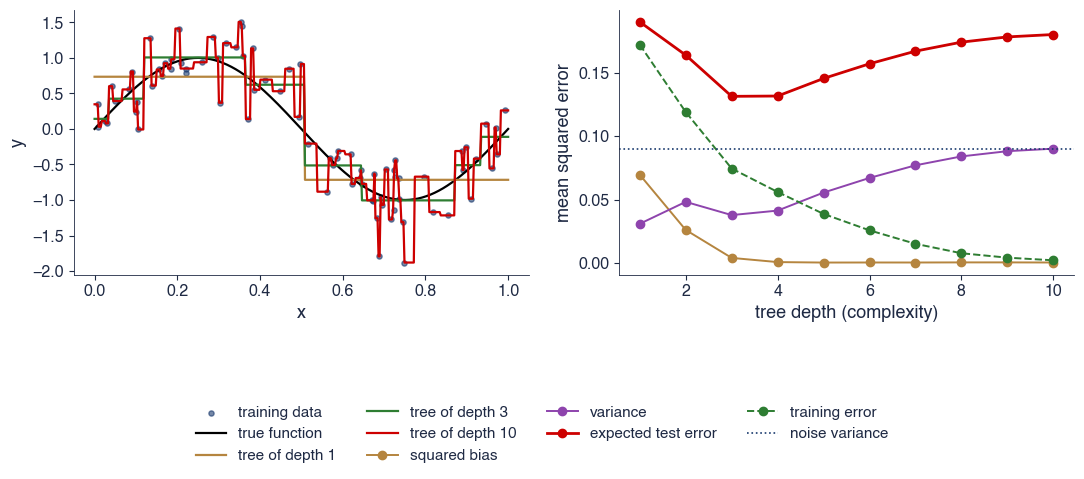

3


In [8]:
def fig_cv_schemes(n=48, k=4, h=3, save=True):
    """Diagram of four schemes on n ordered observations: random K-fold, walk-forward with an expanding window,
    walk-forward with a rolling window, and walk-forward with a gap of h observations before each test block."""
    fig, ax = plt.subplots(figsize=(10.5, 4.8))
    rng = np.random.default_rng(3)
    folds = np.array_split(rng.permutation(n), k)
    colors = {'train': st.MainBlue, 'test': st.IDAred, 'gap': st.Amber, 'unused': 'white'}
    rows = []
    for i in range(k):
        lab = np.array(['train'] * n, dtype=object)
        lab[folds[i]] = 'test'
        rows.append((f'random K-fold, fold {i + 1}', lab))
    size = n // (k + 2)
    for scheme in ('expanding', 'rolling', 'gap'):
        for i in range(k):
            lab = np.array(['unused'] * n, dtype=object)
            end = size * (i + 2)
            start = end - 2 * size if scheme == 'rolling' else 0
            lab[start:end] = 'train'
            if scheme == 'gap':
                lab[end - h:end] = 'gap'
            lab[end:end + size] = 'test'
            name = {'expanding': 'walk-forward, expanding', 'rolling': 'walk-forward, rolling',
                    'gap': 'walk-forward with a gap'}[scheme]
            rows.append((f'{name}, step {i + 1}', lab))
    for j, (name, lab) in enumerate(rows):
        yy = len(rows) - j - 1 - 0.5 * (j // k)
        for t in range(n):
            ax.add_patch(Rectangle((t, yy), 0.92, 0.8, facecolor=colors[lab[t]],
                                   edgecolor=st.MainBlue if lab[t] == 'unused' else 'none', lw=0.3))
        ax.text(-1, yy + 0.4, name, ha='right', va='center', fontsize=9, color='black')
    ax.set_xlim(-20, n + 1)
    ax.set_ylim(-2.4, len(rows) + 0.2)
    ax.axis('off')
    ax.annotate('', xy=(n, -2.0), xytext=(0, -2.0), arrowprops=dict(arrowstyle='->', color='black'))
    ax.text(n / 2, -2.15, 'time', ha='center', va='top', fontsize=10, color='black')
    handles = [Rectangle((0, 0), 1, 1, facecolor=colors[c], edgecolor=st.MainBlue if c == 'unused' else 'none')
               for c in ['train', 'test', 'gap', 'unused']]
    fig.legend(handles, ['training', 'test', 'gap (target overlaps the test block)', 'not used'],
               loc='upper center', bbox_to_anchor=(0.5, 0.04), ncol=4, frameon=False, fontsize=9.5)
    st.check_no_grey(fig)
    if save:
        st.save_fig('tsa_ch9_cv_schemes')
    else:
        plt.show()


def leakage_frame(r, h=21):
    """Features from past returns and a target that overlaps from one day to the next: the sum of the next h returns."""
    X = pd.DataFrame({'m5': r.rolling(5).sum(), 'm21': r.rolling(21).sum(), 'm63': r.rolling(63).sum(),
                      'v21': r.rolling(21).std(), 'v63': r.rolling(63).std()})
    X['y'] = sum(r.shift(-j) for j in range(1, h + 1))
    return X.dropna()


def cv_r2(X, splitter, feats=('m5', 'm21', 'm63', 'v21', 'v63'), seed=SEED):
    """Pooled out-of-sample R^2 of a random forest under a cross-validation scheme (benchmark: the training mean)."""
    y, yh, yb = [], [], []
    for tr, te in splitter.split(X):
        m = RandomForestRegressor(n_estimators=150, min_samples_leaf=5, max_features=0.6, n_jobs=-1, random_state=seed)
        m.fit(X.iloc[tr][list(feats)], X['y'].iloc[tr])
        y += list(X['y'].iloc[te])
        yh += list(m.predict(X.iloc[te][list(feats)]))
        yb += [X['y'].iloc[tr].mean()] * len(te)
    return oos_r2(y, yh, yb)


def leakage_experiment(h=21, n=4000, seed=SEED):
    """Random 5-fold, walk-forward and walk-forward with a gap of h days: R^2 for the sum of the next h daily returns of
    a simulated random walk (nothing to predict) and of the S&P 500 since 2000."""
    rng = np.random.default_rng(seed)
    sim = pd.Series(rng.normal(0, 1, n), index=pd.bdate_range('2000-01-03', periods=n))
    out = {}
    for lab, r in [('sim', sim), ('sp500', log_returns('sp500', '2000-01-01'))]:
        X = leakage_frame(r, h)
        out[lab] = {'n': int(len(X)),
                    'kfold': cv_r2(X, KFold(5, shuffle=True, random_state=seed)),
                    'wf': cv_r2(X, TimeSeriesSplit(5)),
                    'gap': cv_r2(X, TimeSeriesSplit(5, gap=h))}
    return out


def fig_leakage(L=None, save=True):
    """Bar chart of the out-of-sample R^2 under the three schemes."""
    L = L or leakage_experiment()
    fig, ax = plt.subplots(figsize=(9.5, 3.8))
    labs = [('kfold', 'random 5-fold (shuffled)', st.IDAred), ('wf', 'walk-forward', st.MainBlue),
            ('gap', 'walk-forward with a gap of 21 days', st.Forest)]
    xs = np.arange(2)
    for i, (key, lab, col) in enumerate(labs):
        vals = [100 * L[s][key] for s in ('sim', 'sp500')]
        b = ax.bar(xs + (i - 1) * 0.26, vals, width=0.25, color=col, label=lab)
        for rect, v in zip(b, vals):
            ax.text(rect.get_x() + rect.get_width() / 2, v + (1 if v >= 0 else -1), f'{v:.1f}',
                    ha='center', va='bottom' if v >= 0 else 'top', fontsize=10, color='black')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks(xs)
    ax.set_xticklabels(['simulated random walk\n(nothing to predict)', 'S&P 500, 2000-2026'])
    ax.set_ylabel('out-of-sample $R^2$ (%)')
    lo = min(100 * L[s][k] for s in ('sim', 'sp500') for k in ('kfold', 'wf', 'gap'))
    ax.set_ylim(min(lo - 6, -10), max(100 * L[s]['kfold'] for s in ('sim', 'sp500')) + 8)
    st.legend_outside_bottom(ax, ncol=3, y=-0.25)
    st.check_no_grey(fig)
    if save:
        st.save_fig('tsa_ch9_leakage')
    else:
        plt.show()
    return L


def true_f(x):
    """The regression function of the simulation."""
    return np.sin(2 * np.pi * x)


def bias_variance(depths=range(1, 11), n=80, sigma=0.3, B=300, seed=SEED):
    """Regression trees of depth 1..10 on B simulated training sets y = sin(2 pi x) + e, e ~ N(0, sigma^2): squared bias,
    variance and expected test error (bias^2 + variance + sigma^2) on a grid, and the average training error."""
    rng = np.random.default_rng(seed)
    grid = np.linspace(0.01, 0.99, 200)
    out = {}
    for dep in depths:
        P, tr = np.empty((B, len(grid))), []
        for b in range(B):
            x = rng.uniform(0, 1, n)
            y = true_f(x) + rng.normal(0, sigma, n)
            m = DecisionTreeRegressor(max_depth=dep, random_state=0).fit(x[:, None], y)
            P[b] = m.predict(grid[:, None])
            tr.append(np.mean((m.predict(x[:, None]) - y) ** 2))
        bias2 = float(np.mean((P.mean(0) - true_f(grid)) ** 2))
        var = float(np.mean(P.var(0)))
        out[int(dep)] = {'bias2': bias2, 'var': var, 'test': bias2 + var + sigma ** 2, 'train': float(np.mean(tr))}
    return out


def fig_bias_variance(bv=None, n=80, sigma=0.3, seed=SEED, save=True):
    """Left: one simulated sample with trees of depth 1, 3 and 10; right: bias^2, variance, test and training error."""
    bv = bv or bias_variance()
    rng = np.random.default_rng(seed + 1)
    x = rng.uniform(0, 1, n)
    y = true_f(x) + rng.normal(0, sigma, n)
    grid = np.linspace(0, 1, 400)
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.0))
    ax[0].scatter(x, y, s=14, color=st.MainBlue, alpha=0.6, label='training data')
    ax[0].plot(grid, true_f(grid), color='black', lw=1.6, label='true function')
    for dep, col in [(1, st.Amber), (3, st.Forest), (10, st.IDAred)]:
        m = DecisionTreeRegressor(max_depth=dep, random_state=0).fit(x[:, None], y)
        ax[0].plot(grid, m.predict(grid[:, None]), color=col, lw=1.6, label=f'tree of depth {dep}')
    ax[0].set_xlabel('x')
    ax[0].set_ylabel('y')
    d = sorted(bv)
    ax[1].plot(d, [bv[k]['bias2'] for k in d], color=st.Amber, marker='o', label='squared bias')
    ax[1].plot(d, [bv[k]['var'] for k in d], color=st.Purple, marker='o', label='variance')
    ax[1].plot(d, [bv[k]['test'] for k in d], color=st.IDAred, marker='o', lw=2, label='expected test error')
    ax[1].plot(d, [bv[k]['train'] for k in d], color=st.Forest, marker='o', ls='--', label='training error')
    ax[1].axhline(sigma ** 2, color=st.MainBlue, ls=':', lw=1.2, label='noise variance')
    ax[1].set_xlabel('tree depth (complexity)')
    ax[1].set_ylabel('mean squared error')
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    fig.tight_layout(rect=(0, 0.13, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('tsa_ch9_bias_variance')
    else:
        plt.show()
    best = min(bv, key=lambda k: bv[k]['test'])
    return {'best_depth': int(best), 'sigma2': sigma ** 2, 'n': n, **{f'd{k}': bv[k] for k in (1, 3, best, 10)}}


fig_cv_schemes(save=False)
print(fig_leakage(save=False))
bv = fig_bias_variance(save=False)
print(bv['best_depth'])

## 3. Ridge and lasso

- Coefficient paths on the 30 standardised load features; the lasso penalty chosen walk-forward.

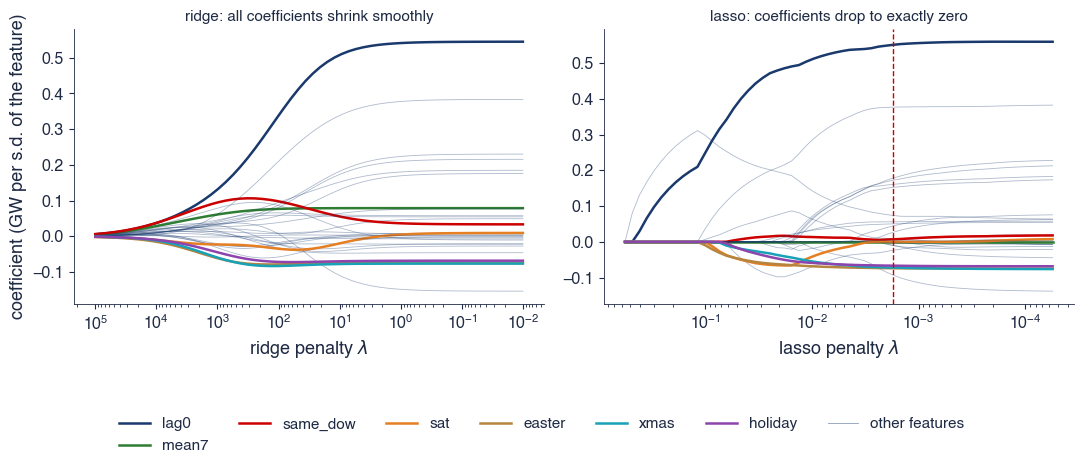

{'alpha_cv': 0.0017269312344170532, 'kept': ['lag0', 'lag1', 'lag2', 'lag3', 'lag6', 'lag7', 'lag8', 'lag12', 'lag13', 'mean28', 'mon', 'tue', 'wed', 'thu', 'fri', 'sin1', 'cos1', 'sin2', 'cos2', 'easter', 'xmas', 'holiday'], 'n_kept': 22, 'top': [('lag0', 0.5516114421892605), ('mon', 0.37590148142204777), ('wed', 0.17805197154565403), ('thu', 0.17173111439380118), ('tue', 0.15993216647558822), ('fri', 0.1519301270511184)], 'first3': ['lag6', 'lag0', 'lag13'], 'n': 1249, 'p': 30}


In [9]:
def shrinkage_paths(y=None, end=CV_FIRST):
    """Ridge and lasso coefficient paths of the standardised load features (h = 1), data up to the first origin."""
    y = load_daily() if y is None else y
    F = direct_frame(y.loc[:end], 1).dropna()
    Z = StandardScaler().fit_transform(F[FEATS].values)
    t = F['y'].values - F['y'].mean()
    alphas_l, coefs_l, _ = lasso_path(Z, t, n_alphas=60, eps=1e-4)
    lams = np.logspace(-2, 5, 60)
    coefs_r = np.array([np.linalg.solve(Z.T @ Z + l * np.eye(Z.shape[1]), Z.T @ t) for l in lams]).T
    cv = LassoCV(cv=TimeSeriesSplit(5), n_alphas=60, eps=1e-4).fit(Z, t)
    kept = [FEATS[j] for j in np.flatnonzero(np.abs(cv.coef_) > 1e-8)]
    order = np.argsort(-np.abs(cv.coef_))
    top = [(FEATS[j], float(cv.coef_[j])) for j in order[:6]]
    entry = {}
    for j, f in enumerate(FEATS):
        nz = np.flatnonzero(np.abs(coefs_l[j]) > 1e-10)
        entry[f] = float(alphas_l[nz[0]]) if len(nz) else 0.0
    first3 = sorted(entry, key=lambda k: -entry[k])[:3]
    return {'alphas_l': alphas_l, 'coefs_l': coefs_l, 'lams': lams, 'coefs_r': coefs_r, 'alpha_cv': float(cv.alpha_),
            'kept': kept, 'n_kept': len(kept), 'top': top, 'first3': first3, 'n': int(len(F)), 'p': len(FEATS)}


def fig_shrinkage(S=None, save=True):
    """Coefficient paths: ridge (left) and lasso (right) against the penalty; dashed: the lasso penalty chosen by
    walk-forward cross-validation."""
    S = S or shrinkage_paths()
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
    for j, f in enumerate(FEATS):
        col = HIGHLIGHT.get(f)
        kw = dict(color=col, lw=1.8, label=f) if col else dict(color=st.MainBlue, lw=0.6, alpha=0.35, label='_nolegend_')
        ax[0].plot(S['lams'], S['coefs_r'][j], **kw)
        ax[1].plot(S['alphas_l'], S['coefs_l'][j], **{**kw, 'label': '_nolegend_'})
    ax[0].set_xscale('log')
    ax[1].set_xscale('log')
    ax[0].set_xlabel('ridge penalty $\\lambda$')
    ax[1].set_xlabel('lasso penalty $\\lambda$')
    ax[0].set_ylabel('coefficient (GW per s.d. of the feature)')
    ax[1].axvline(S['alpha_cv'], color=st.IDAred, ls='--', lw=1)
    ax[0].set_title('ridge: all coefficients shrink smoothly', fontsize=11)
    ax[1].set_title('lasso: coefficients drop to exactly zero', fontsize=11)
    ax[1].invert_xaxis()
    ax[0].invert_xaxis()
    h0 = plt.Line2D([], [], color=st.MainBlue, lw=0.6, alpha=0.5, label='other features')
    hh, ll = ax[0].get_legend_handles_labels()
    fig.legend(hh + [h0], ll + ['other features'], loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=7, frameon=False)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('tsa_ch9_shrinkage')
    else:
        plt.show()
    return {k: S[k] for k in ('alpha_cv', 'kept', 'n_kept', 'top', 'first3', 'n', 'p')}


print(fig_shrinkage(save=False))

## 4. Trees, random forest and gradient boosting

- A depth-2 tree, ensembles on validation data, the extrapolation failure.

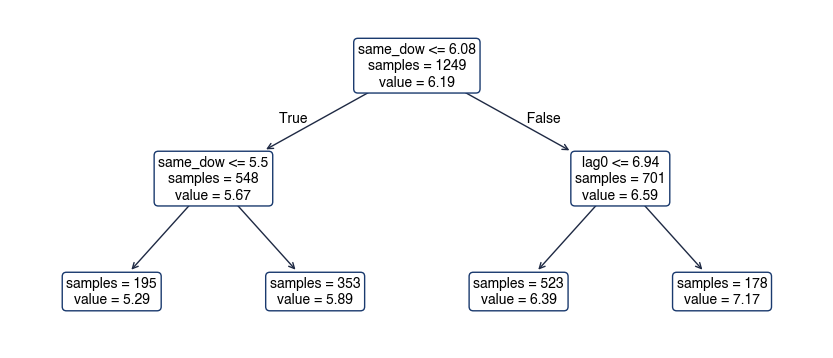

{'root': {'feat': 'same_dow', 'thr': 6.0834269523620605, 'n': 1249, 'value': 6.1881075854850565}, 'leaves': [{'n': 195, 'value': 5.287767279380345}, {'n': 353, 'value': 5.888057302880071}, {'n': 523, 'value': 6.391185839905993}, {'n': 178, 'value': 7.172794003394196}], 'kids': [{'feat': 'same_dow', 'thr': 5.502854108810425}, {'feat': 'lag0', 'thr': 6.944158554077148}], 'r2': 0.6369473971556558, 'n': 1249}


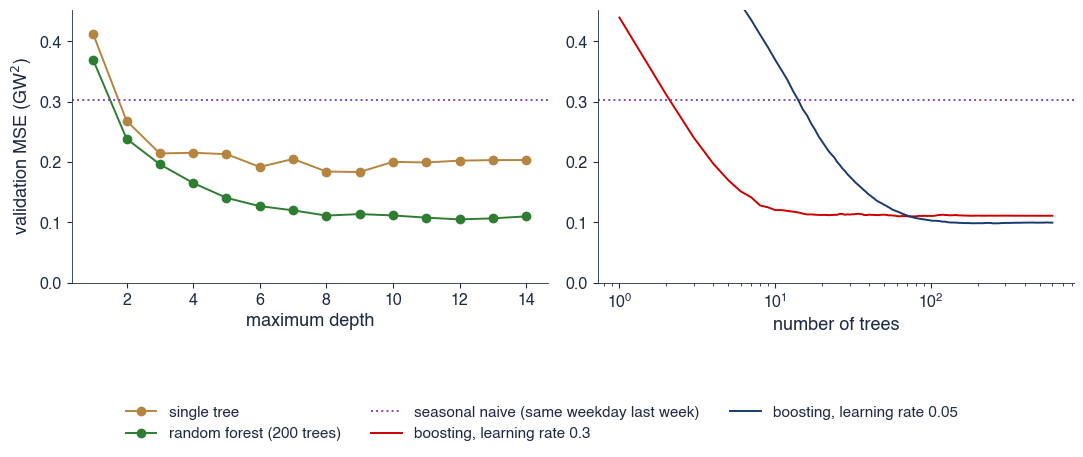

{'tree_best': 0.18337164824392232, 'tree_best_d': 9, 'rf_best': 0.10471552519246467, 'rf_best_d': 12, 'naive': 0.30345857434628926, 'gb03_min': 0.10959128004645531, 'gb03_min_it': 72, 'gb03_end': 0.11077327891282664, 'gb005_min': 0.09813999920694196, 'gb005_min_it': 256, 'gb005_end': 0.09935405125076978, 'n_tr': 1069, 'n_va': 180}


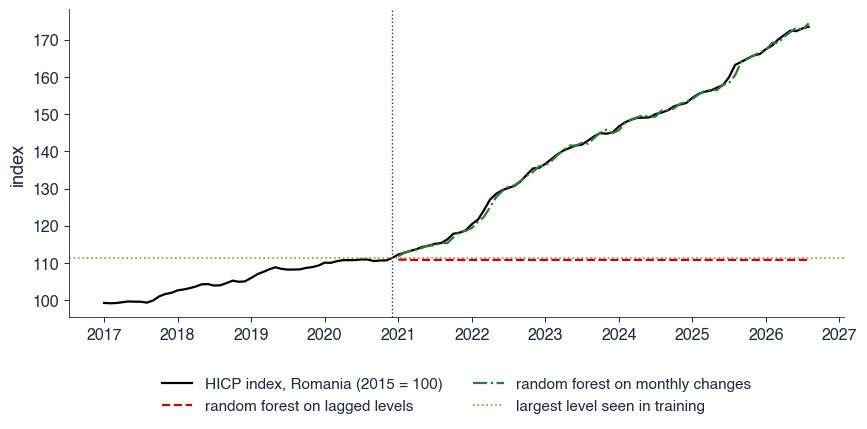

{'max_train': 111.32, 'last': 173.45, 'last_d': '2026-08-01', 'f_l_last': 110.84330044973545, 'f_l_max': 110.91243850529092, 'rmse_l': 36.90968173611106, 'rmse_c': 0.7084411429833168, 'n_te': 68}


In [10]:
def fig_tree(y=None, end=CV_FIRST, save=True):
    """A regression tree of depth 2 for tomorrow's load (h = 1)."""
    y = load_daily() if y is None else y
    F = direct_frame(y.loc[:end], 1).dropna()
    F = F.assign(weekend=1 - F[['mon', 'tue', 'wed', 'thu', 'fri']].sum(axis=1))
    cols = ['lag0', 'same_dow', 'weekend', 'holiday', 'xmas', 'easter']
    m = DecisionTreeRegressor(max_depth=2, min_samples_leaf=20, random_state=0).fit(F[cols], F['y'])
    fig, ax = plt.subplots(figsize=(10.5, 4.4))
    plot_tree(m, feature_names=cols, filled=False, impurity=False, precision=2, fontsize=10, ax=ax, rounded=True)
    for t in ax.texts:
        t.set_color('black')
        bb = t.get_bbox_patch()
        if bb is not None:
            bb.set_edgecolor(st.MainBlue)
            bb.set_facecolor('white')
    st.check_no_grey(fig)
    if save:
        st.save_fig('tsa_ch9_tree')
    else:
        plt.show()
    tr = m.tree_
    root = {'feat': cols[tr.feature[0]], 'thr': float(tr.threshold[0]), 'n': int(tr.n_node_samples[0]),
            'value': float(tr.value[0][0][0])}
    leaves = [{'n': int(tr.n_node_samples[i]), 'value': float(tr.value[i][0][0])} for i in range(tr.node_count)
              if tr.children_left[i] == -1]
    kids = [{'feat': cols[tr.feature[i]], 'thr': float(tr.threshold[i])} for i in (tr.children_left[0], tr.children_right[0])
            if tr.children_left[i] != -1]
    r2 = float(m.score(F[cols], F['y']))
    return {'root': root, 'leaves': leaves, 'kids': kids, 'r2': r2, 'n': int(len(F))}


def ensemble_curves(y=None, split='2024-12-31', end=CV_FIRST, seed=SEED):
    """Validation MSE (January - June 2025, h = 1) of a single tree and a random forest for depth 1..14, and of
    histogram gradient boosting against the number of trees for two learning rates."""
    y = load_daily() if y is None else y
    F = direct_frame(y.loc[:end], 1).dropna()
    tr, va = F.loc[:split], F.loc[pd.Timestamp(split) + pd.Timedelta(days=1):]
    out = {'depth': list(range(1, 15)), 'tree': [], 'rf': []}
    for dep in out['depth']:
        t = DecisionTreeRegressor(max_depth=dep, random_state=seed).fit(tr[FEATS], tr['y'])
        out['tree'].append(float(np.mean((t.predict(va[FEATS]) - va['y']) ** 2)))
        f = RandomForestRegressor(n_estimators=200, max_depth=dep, max_features=0.5, n_jobs=-1, random_state=seed)
        f.fit(tr[FEATS], tr['y'])
        out['rf'].append(float(np.mean((f.predict(va[FEATS]) - va['y']) ** 2)))
    out['iters'] = list(range(1, 601))
    for lr in (0.3, 0.05):
        g = HistGradientBoostingRegressor(max_iter=600, learning_rate=lr, max_leaf_nodes=15, min_samples_leaf=20,
                                          early_stopping=False, random_state=seed).fit(tr[FEATS], tr['y'])
        out[f'gb{lr}'] = [float(np.mean((p - va['y'].values) ** 2)) for p in g.staged_predict(va[FEATS])]
    out['naive'] = float(np.mean((va['same_dow'] - va['y']) ** 2))
    out['n_tr'], out['n_va'] = int(len(tr)), int(len(va))
    return out


def fig_ensembles(E=None, save=True):
    """Left: validation MSE against depth, single tree and random forest; right: boosting against the number of trees."""
    E = E or ensemble_curves()
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.0))
    ax[0].plot(E['depth'], E['tree'], color=st.Amber, marker='o', label='single tree')
    ax[0].plot(E['depth'], E['rf'], color=st.Forest, marker='o', label='random forest (200 trees)')
    ax[0].axhline(E['naive'], color=st.Purple, ls=':', label='seasonal naive (same weekday last week)')
    ax[0].set_xlabel('maximum depth')
    ax[0].set_ylabel('validation MSE (GW$^2$)')
    ax[1].plot(E['iters'], E['gb0.3'], color=st.IDAred, label='boosting, learning rate 0.3')
    ax[1].plot(E['iters'], E['gb0.05'], color=st.MainBlue, label='boosting, learning rate 0.05')
    ax[1].axhline(E['naive'], color=st.Purple, ls=':', label='_nolegend_')
    ax[1].set_xscale('log')
    ax[1].set_xlabel('number of trees')
    ax[1].set_ylim(0, max(E['naive'], E['tree'][0]) * 1.1)
    ax[0].set_ylim(0, max(E['naive'], E['tree'][0]) * 1.1)
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.1, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('tsa_ch9_ensembles')
    else:
        plt.show()
    j = int(np.argmin(E['rf']))
    return {'tree_best': float(min(E['tree'])), 'tree_best_d': int(E['depth'][int(np.argmin(E['tree']))]),
            'rf_best': float(E['rf'][j]), 'rf_best_d': int(E['depth'][j]), 'naive': E['naive'],
            'gb03_min': float(min(E['gb0.3'])), 'gb03_min_it': int(np.argmin(E['gb0.3']) + 1),
            'gb03_end': float(E['gb0.3'][-1]), 'gb005_min': float(min(E['gb0.05'])),
            'gb005_min_it': int(np.argmin(E['gb0.05']) + 1), 'gb005_end': float(E['gb0.05'][-1]),
            'n_tr': E['n_tr'], 'n_va': E['n_va']}


def hicp(geo='RO'):
    """Monthly HICP index (2015 = 100) of one EU country, Eurostat prc_hicp_minr."""
    for attempt in range(4):              # the public API sometimes drops a connection: retry
        try:
            s = read_eurostat(HICP[0], HICP[1].format(geo))
            break
        except Exception:
            if attempt == 3:
                raise
            import time
            time.sleep(5)
    s.index.freq = None
    return s.rename(geo)


def fig_extrapolation(split='2020-12-01', seed=SEED, save=True):
    """Trees cannot extrapolate: one-month-ahead forecasts of the Romanian HICP index level from a random forest on
    lagged levels, a random forest on monthly log changes, and an AR(12) on log changes, all trained up to 2020."""
    p = hicp('RO').loc['2005-01-01':]
    lp = np.log(p)
    lv = pd.DataFrame({f'l{j}': p.shift(j) for j in range(1, 13)}).assign(y=p)
    ch = pd.DataFrame({f'l{j}': 100 * lp.diff().shift(j) for j in range(1, 13)}).assign(y=100 * lp.diff())
    lv, ch = lv.dropna(), ch.dropna()
    tr_l, tr_c = lv.loc[:split], ch.loc[:split]
    rf_l = RandomForestRegressor(300, min_samples_leaf=2, random_state=seed, n_jobs=-1).fit(tr_l.drop(columns='y'), tr_l['y'])
    rf_c = RandomForestRegressor(300, min_samples_leaf=2, random_state=seed, n_jobs=-1).fit(tr_c.drop(columns='y'), tr_c['y'])
    te = lv.index[lv.index > split]
    f_l = pd.Series(rf_l.predict(lv.loc[te].drop(columns='y')), index=te)
    f_c = pd.Series(p.shift(1).loc[te].values * np.exp(rf_c.predict(ch.loc[te].drop(columns='y')) / 100), index=te)
    fig, ax = plt.subplots(figsize=(10, 4.0))
    s = p.loc['2017-01-01':]
    ax.plot(s.index, s.values, color='black', lw=1.6, label='HICP index, Romania (2015 = 100)')
    ax.plot(f_l.index, f_l.values, color=st.IDAred, lw=1.6, ls='--', label='random forest on lagged levels')
    ax.plot(f_c.index, f_c.values, color=st.Forest, lw=1.6, ls='-.', label='random forest on monthly changes')
    ax.axhline(tr_l['y'].max(), color=st.Amber, ls=':', lw=1.2, label='largest level seen in training')
    ax.axvline(pd.Timestamp(split), color=st.MainBlue, ls=':', lw=1)
    ax.set_ylabel('index')
    st.legend_outside_bottom(ax, ncol=2, y=-0.15)
    st.check_no_grey(fig)
    if save:
        st.save_fig('tsa_ch9_extrapolation')
    else:
        plt.show()
    e_l = (p.loc[te] - f_l)
    e_c = (p.loc[te] - f_c)
    return {'max_train': float(tr_l['y'].max()), 'last': float(p.iloc[-1]), 'last_d': str(p.index[-1].date()),
            'f_l_last': float(f_l.iloc[-1]), 'f_l_max': float(f_l.max()), 'rmse_l': float(np.sqrt(np.mean(e_l ** 2))),
            'rmse_c': float(np.sqrt(np.mean(e_c ** 2))), 'n_te': int(len(te))}


print(fig_tree(save=False))
print(fig_ensembles(save=False))
print(fig_extrapolation(save=False))

## 5. Neural networks

- The MLP and its activation functions, the RNN and the LSTM cell; a small LSTM and a multi-output MLP trained on the load up to the first origin.

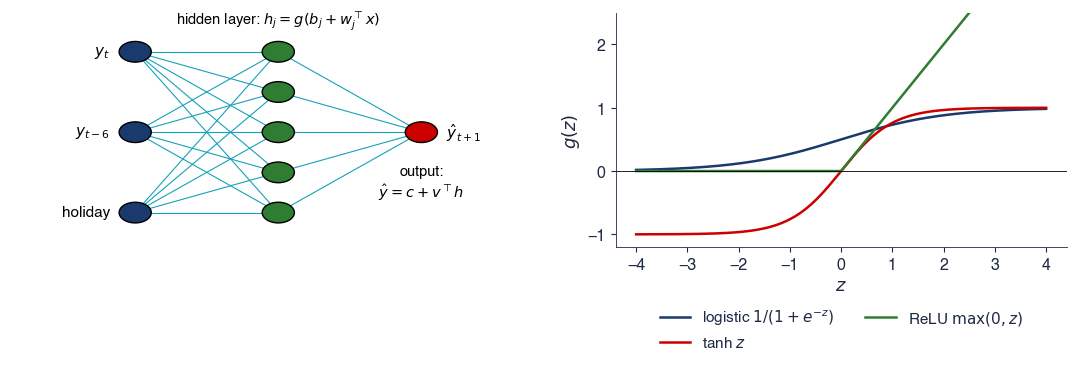

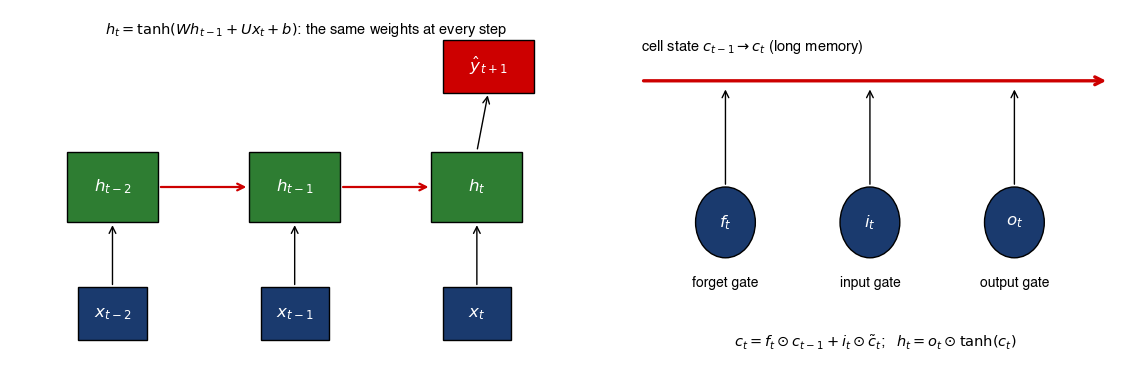

LSTM loss: first epoch 0.93 last epoch 0.23


,actual,LSTM,MLP
0,5.964,6.354,6.334
1,6.000,6.346,6.306
2,6.284,6.321,6.298
3,6.485,6.226,6.271
4,5.835,5.699,5.661
5,5.439,5.077,5.152
6,6.548,5.970,6.138
7,6.722,6.279,6.365
8,6.685,6.293,6.352
9,6.073,6.261,6.329


In [11]:
def fig_mlp(save=True):
    """Left: a multilayer perceptron with 3 inputs, 5 hidden neurons and one output; right: activation functions."""
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.0), gridspec_kw={'width_ratios': [1.15, 1]})
    layers = [['$y_t$', '$y_{t-6}$', 'holiday'], [''] * 5, ['$\\hat y_{t+1}$']]
    xs = [0.1, 0.5, 0.9]
    pos = []
    for x, lay in zip(xs, layers):
        ys = np.linspace(0.85, 0.15, len(lay)) if len(lay) > 1 else [0.5]
        pos.append([(x, y) for y in ys])
    for a, b in zip(pos[:-1], pos[1:]):
        for p in a:
            for q in b:
                ax[0].plot([p[0], q[0]], [p[1], q[1]], color=st.Teal, lw=0.8, zorder=1)
    for i, (lay, ps) in enumerate(zip(layers, pos)):
        col = [st.MainBlue, st.Forest, st.IDAred][i]
        for (x, y), lab in zip(ps, lay):
            ax[0].add_patch(Circle((x, y), 0.045, facecolor=col, edgecolor='black', zorder=2))
            if lab:
                ax[0].text(x + (-0.07 if i == 0 else 0.07), y, lab, ha='right' if i == 0 else 'left', va='center',
                           fontsize=11, color='black')
    ax[0].text(0.5, 0.97, 'hidden layer: $h_j = g(b_j + w_j^\\top x)$', ha='center', fontsize=10.5, color='black')
    ax[0].text(0.9, 0.36, 'output:\n$\\hat y = c + v^\\top h$', ha='center', va='top', fontsize=10.5, color='black')
    ax[0].set_xlim(-0.25, 1.2)
    ax[0].set_ylim(0, 1.02)
    ax[0].axis('off')
    z = np.linspace(-4, 4, 400)
    ax[1].plot(z, 1 / (1 + np.exp(-z)), color=st.MainBlue, lw=1.8, label='logistic $1/(1+e^{-z})$')
    ax[1].plot(z, np.tanh(z), color=st.IDAred, lw=1.8, label='tanh $z$')
    ax[1].plot(z, np.maximum(z, 0), color=st.Forest, lw=1.8, label='ReLU $\\max(0, z)$')
    ax[1].set_ylim(-1.2, 2.5)
    ax[1].axhline(0, color='black', lw=0.6)
    ax[1].set_xlabel('$z$')
    ax[1].set_ylabel('$g(z)$')
    st.legend_outside_bottom(ax[1], ncol=2, y=-0.2)
    fig.tight_layout()
    st.check_no_grey(fig)
    if save:
        st.save_fig('tsa_ch9_mlp')
    else:
        plt.show()


def fig_rnn(save=True):
    """A recurrent network unrolled in time (left) and the LSTM cell state with its three gates (right)."""
    fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.9), gridspec_kw={'width_ratios': [1.2, 1]})
    a = ax[0]
    a.set_xlim(0, 10.5)
    a.set_ylim(0, 6)
    a.axis('off')
    labs = ['$t-2$', '$t-1$', '$t$']
    for i, lab in enumerate(labs):
        x = 1 + 3.2 * i
        a.add_patch(Rectangle((x, 2.4), 1.6, 1.2, facecolor=st.Forest, edgecolor='black'))
        a.text(x + 0.8, 3.0, f'$h_{{{lab[1:-1]}}}$', ha='center', va='center', color='white', fontsize=12)
        a.add_patch(Rectangle((x + 0.2, 0.4), 1.2, 0.9, facecolor=st.MainBlue, edgecolor='black'))
        a.text(x + 0.8, 0.85, f'$x_{{{lab[1:-1]}}}$', ha='center', va='center', color='white', fontsize=12)
        a.add_patch(FancyArrowPatch((x + 0.8, 1.3), (x + 0.8, 2.4), arrowstyle='->', mutation_scale=12, color='black'))
        if i < 2:
            a.add_patch(FancyArrowPatch((x + 1.6, 3.0), (x + 3.2, 3.0), arrowstyle='->', mutation_scale=12,
                                        color=st.IDAred, lw=1.6))
    a.add_patch(Rectangle((7.6, 4.6), 1.6, 0.9, facecolor=st.IDAred, edgecolor='black'))
    a.text(8.4, 5.05, '$\\hat y_{t+1}$', ha='center', va='center', color='white', fontsize=12)
    a.add_patch(FancyArrowPatch((8.2, 3.6), (8.4, 4.6), arrowstyle='->', mutation_scale=12, color='black'))
    a.text(5.2, 5.6, '$h_t = \\tanh(W h_{t-1} + U x_t + b)$: the same weights at every step', ha='center',
           fontsize=10.5, color='black')
    b = ax[1]
    b.set_xlim(0, 10)
    b.set_ylim(0, 6)
    b.axis('off')
    b.add_patch(FancyArrowPatch((0.3, 4.8), (9.7, 4.8), arrowstyle='->', mutation_scale=14, color=st.IDAred, lw=2.4))
    b.text(0.3, 5.3, 'cell state $c_{t-1} \\rightarrow c_t$ (long memory)', fontsize=10.5, color='black')
    for x, g, txt in [(1.4, 'f', 'forget'), (4.3, 'i', 'input'), (7.2, 'o', 'output')]:
        b.add_patch(Circle((x + 0.6, 2.4), 0.6, facecolor=st.MainBlue, edgecolor='black'))
        b.text(x + 0.6, 2.4, f'${g}_t$', ha='center', va='center', color='white', fontsize=12)
        b.text(x + 0.6, 1.3, f'{txt} gate', ha='center', fontsize=10, color='black')
        b.add_patch(FancyArrowPatch((x + 0.6, 3.0), (x + 0.6, 4.7), arrowstyle='->', mutation_scale=12, color='black'))
    b.text(5.0, 0.3, '$c_t = f_t \\odot c_{t-1} + i_t \\odot \\tilde c_t$;   $h_t = o_t \\odot \\tanh(c_t)$',
           ha='center', fontsize=10.5, color='black')
    fig.tight_layout()
    st.check_no_grey(fig)
    if save:
        st.save_fig('tsa_ch9_rnn')
    else:
        plt.show()


fig_mlp(save=False)
fig_rnn(save=False)
o = pd.Timestamp(CV_FIRST)
f_lstm, losses = forecast_lstm(y, o)
print('LSTM loss: first epoch', round(losses[0], 3), 'last epoch', round(losses[-1], 3))
pd.DataFrame({'actual': y.loc[o + pd.Timedelta(days=1):].iloc[:CV_H].values, 'LSTM': f_lstm, 'MLP': forecast_mlp(y, o)}).round(3)

## 6. Electricity load: ML against Chapter 4

- The 26 origins and the 14-day horizon of Chapter 4. Ridge and gradient boosting (direct and recursive) are recomputed here (a few minutes); the random forest, the MLP and the LSTM take longer, so their walk-forward forecasts are read from `ch9_load_ml.csv`, written by `load_ml_cv` in `generate_all_charts.py`.
- Slides: MASE of DHR 0.89, ridge 0.90, GB direct 0.97, LSTM 1.16.

                  MAE   RMSE   MASE
model                              
Seasonal naive  0.396  0.529  1.282
ETS             0.381  0.492  1.234
SARIMA          0.384  0.477  1.242
DHR             0.276  0.350  0.894
Combination     0.305  0.380  0.988
Ridge           0.277  0.337  0.897
RF              0.308  0.388  0.998
GB direct       0.298  0.369  0.966
GB recursive    0.307  0.388  0.993
MLP             0.294  0.362  0.951
LSTM            0.357  0.447  1.155
{'Seasonal naive|DHR': 0.0, 'ETS|DHR': 0.015, 'SARIMA|DHR': 0.003, 'Combination|DHR': 0.065, 'Ridge|DHR': 0.942, 'RF|DHR': 0.068, 'GB direct|DHR': 0.163, 'GB recursive|DHR': 0.113, 'MLP|DHR': 0.546, 'LSTM|DHR': 0.016}


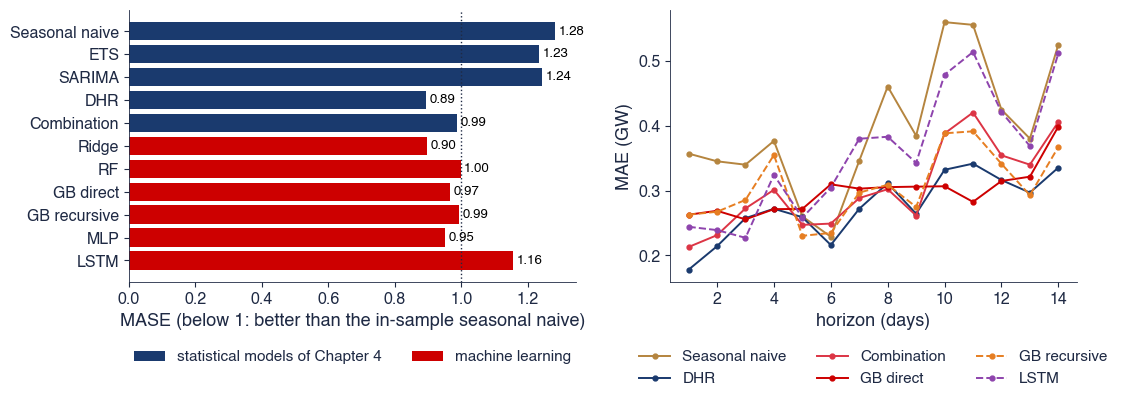

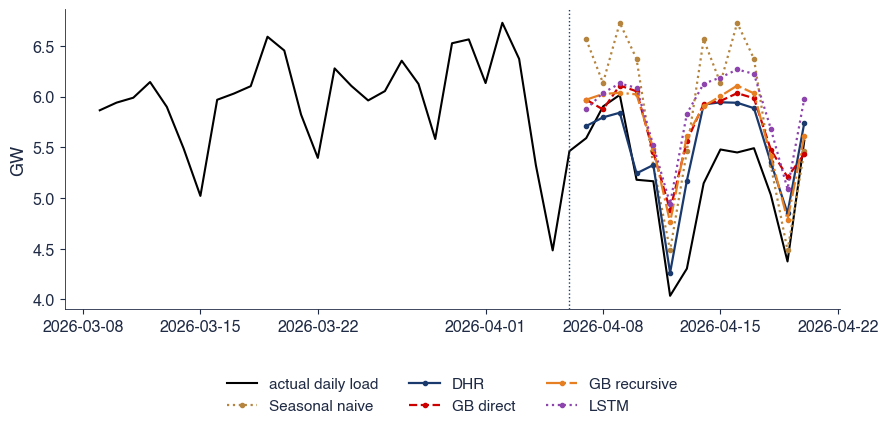

{'origin': '2026-04-06', 'mae': {'Combination': 0.39384071428571427, 'DHR': 0.34408785714285717, 'ETS': 0.2987135714285714, 'GB direct': 0.5359342961543269, 'GB recursive': 0.5029845597151322, 'LSTM': 0.6606935714285714, 'MLP': 0.1458614285714286, 'Prophet': 0.6155342857142857, 'RF': 0.5621271428571429, 'Ridge': 0.29461130236445265, 'SARIMA': 0.5844699999999999, 'Seasonal naive': 0.6859457142857143, 'TBATS': 0.3089742857142857}}


In [12]:
def load_ml_cv(y=None, models=('Ridge', 'RF', 'GB direct', 'GB recursive', 'MLP', 'LSTM'), save_csv=True):
    """Walk-forward evaluation on the 26 origins of Chapter 4 (expanding window, horizon 14 days)."""
    y = load_daily() if y is None else y
    frames = {h: direct_frame(y, h) for h in range(1, CV_H + 1)}
    rows = []
    for o in origins(y):
        idx = pd.date_range(o + pd.Timedelta(days=1), periods=CV_H, freq='D')
        act = y.reindex(idx).values
        f = {}
        for name in models:
            if name in direct_models():
                f[name] = forecast_direct(y, o, direct_models()[name], frames=frames)
            elif name == 'GB recursive':
                f[name] = forecast_recursive(y, o, make_gb)
            elif name == 'MLP':
                f[name] = forecast_mlp(y, o)
            elif name == 'LSTM':
                f[name] = forecast_lstm(y, o)[0]
        for k, v in f.items():
            for j in range(CV_H):
                rows.append({'origin': o, 'model': k, 'h': j + 1, 'date': idx[j], 'actual': act[j], 'fc': v[j],
                             'err': act[j] - v[j]})
    E = pd.DataFrame(rows)
    if save_csv:
        E.round(5).to_csv(os.path.join(HERE, 'ch9_load_ml.csv'), index=False)
    return E


def ch9_file(name):
    """A file of Quantlets/Ch_09: local copy if the code runs inside the repository, else the TSA repository on GitHub."""
    local = [os.path.join(HERE, name)] + [os.path.join(d, 'Quantlets', 'Ch_09', name) for d in ('.', '..', '../..', '../../..')]
    return next((p for p in local if os.path.exists(p)),
                'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/Quantlets/Ch_09/' + name)


def saved_load_ml():
    """The walk-forward forecasts of the ML models saved by this script (Quantlets/Ch_09/ch9_load_ml.csv)."""
    return pd.read_csv(ch9_file('ch9_load_ml.csv'), parse_dates=['origin', 'date'])


def ch4_errors():
    """The forecast errors of the statistical models of Chapter 4 on the same origins (Quantlets/Ch_04/ch4_load_cv.csv)."""
    local = [os.path.join(HERE, '..', 'Ch_04', 'ch4_load_cv.csv')] + [os.path.join(d, 'Quantlets', 'Ch_04', 'ch4_load_cv.csv')
                                                                      for d in ('.', '..', '../..', '../../..')]
    src = next((p for p in local if os.path.exists(p)), LOAD_RAW + 'ch4_load_cv.csv')
    return pd.read_csv(src, parse_dates=['origin', 'date'])


def load_summary(E_ml, E_stat, y=None):
    """MAE, RMSE, MASE (scale: in-sample MAE of the weekly seasonal naive method on the first training sample, as in
    Chapter 4) of every model; DM tests on origin-average absolute errors against DHR and the seasonal naive method."""
    y = load_daily() if y is None else y
    E = pd.concat([E_stat[E_stat['model'].isin(['Seasonal naive', 'ETS', 'SARIMA', 'DHR', 'Combination'])], E_ml])
    tr = y.loc[:E['origin'].min()].values
    scale = float(np.mean(np.abs(tr[7:] - tr[:-7])))
    g = E.groupby('model')['err']
    tab = pd.DataFrame({'MAE': g.apply(lambda e: np.mean(np.abs(e))), 'RMSE': g.apply(lambda e: np.sqrt(np.mean(e ** 2)))})
    tab['MASE'] = tab['MAE'] / scale
    order = ['Seasonal naive', 'ETS', 'SARIMA', 'DHR', 'Combination', 'Ridge', 'RF', 'GB direct', 'GB recursive', 'MLP', 'LSTM']
    tab = tab.loc[[m for m in order if m in tab.index]]
    W = E.assign(ae=E['err'].abs()).groupby(['model', 'origin'])['ae'].mean()
    dm = {}
    for m in tab.index:
        for ref in ('DHR', 'Seasonal naive'):
            if m != ref:
                dm[f'{m}|{ref}'] = dm_raw(W.loc[m].values, W.loc[ref].values)
    byh = E.assign(ae=E['err'].abs()).groupby(['model', 'h'])['ae'].mean().unstack(0)
    return tab, dm, scale, byh


def fig_load_results(tab, byh, save=True):
    """Left: MASE of every model (bars); right: MAE by horizon of the main models."""
    fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.3), gridspec_kw={'width_ratios': [1.1, 1]})
    names = list(tab.index)
    stat = ['Seasonal naive', 'ETS', 'SARIMA', 'DHR', 'Combination']
    cols = [st.MainBlue if m in stat else st.IDAred for m in names]
    ax[0].barh(range(len(names)), tab['MASE'].values, color=cols)
    ax[0].barh([0], [0], color=st.MainBlue, label='statistical models of Chapter 4')
    ax[0].barh([0], [0], color=st.IDAred, label='machine learning')
    for i, v in enumerate(tab['MASE'].values):
        ax[0].text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=9.5, color='black')
    ax[0].set_yticks(range(len(names)))
    ax[0].set_yticklabels(names)
    ax[0].invert_yaxis()
    ax[0].axvline(1, color=st.DarkText, ls=':', lw=1)
    ax[0].set_xlabel('MASE (below 1: better than the in-sample seasonal naive)')
    ax[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2, frameon=False)
    for m in ['Seasonal naive', 'DHR', 'Combination', 'GB direct', 'GB recursive', 'LSTM']:
        if m in byh:
            ax[1].plot(byh.index, byh[m].values, marker='o', ms=3.5, color=MCOL[m], label=m,
                       ls='--' if m in ('GB recursive', 'LSTM') else '-')
    ax[1].set_xlabel('horizon (days)')
    ax[1].set_ylabel('MAE (GW)')
    st.legend_outside_bottom(ax[1], ncol=3, y=-0.2)
    fig.tight_layout()
    st.check_no_grey(fig)
    if save:
        st.save_fig('tsa_ch9_load_results')
    else:
        plt.show()


def fig_load_forecasts(E_ml, E_stat, y=None, origin=None, save=True):
    """Forecasts from one origin (the one with Orthodox Easter in the test window): actual load, DHR, GB direct and
    GB recursive."""
    y = load_daily() if y is None else y
    E = pd.concat([E_stat, E_ml])
    if origin is None:
        cal = calendar(y.index)
        eas = cal.index[cal['easter'] > 0]
        cand = [o for o in sorted(E['origin'].unique()) if any((eas > o) & (eas <= o + pd.Timedelta(days=CV_H)))]
        origin = pd.Timestamp(cand[-1])
    fig, ax = plt.subplots(figsize=(10, 3.9))
    s = y.loc[origin - pd.Timedelta(days=28):origin + pd.Timedelta(days=CV_H)]
    ax.plot(s.index, s.values, color='black', lw=1.5, label='actual daily load')
    for m, ls in [('Seasonal naive', ':'), ('DHR', '-'), ('GB direct', '--'), ('GB recursive', '-.'), ('LSTM', ':')]:
        e = E[(E['origin'] == origin) & (E['model'] == m)]
        ax.plot(e['date'], e['fc'], color=MCOL[m], lw=1.6, ls=ls, marker='o', ms=3, label=m)
    ax.axvline(origin, color=st.MainBlue, ls=':', lw=1)
    ax.set_ylabel('GW')
    st.legend_outside_bottom(ax, ncol=3, y=-0.18)
    st.check_no_grey(fig)
    if save:
        st.save_fig('tsa_ch9_load_forecasts')
    else:
        plt.show()
    ee = E[E['origin'] == origin].assign(ae=lambda d: d['err'].abs()).groupby('model')['ae'].mean()
    return {'origin': str(origin.date()), 'mae': {k: float(v) for k, v in ee.items()}}


E_new = load_ml_cv(y, models=('Ridge', 'GB direct', 'GB recursive'), save_csv=False)
E_saved = saved_load_ml()
E_ml = pd.concat([E_new, E_saved[E_saved['model'].isin(['RF', 'MLP', 'LSTM'])]])
E_st = ch4_errors()
tab, dm, scale, byh = load_summary(E_ml, E_st, y)
print(tab.round(3))
print({k: round(v['p'], 3) for k, v in dm.items() if k.endswith('|DHR')})
fig_load_results(tab, byh, save=False)
print(fig_load_forecasts(E_ml, E_st, y, save=False))

## 7. Feature importance and prediction intervals

- Permutation importance of gradient boosting for horizons 1 and 14 days.
- 90% intervals by quantile boosting and split conformal prediction; to keep the notebook short, every second origin is used here (the slides use all 26).

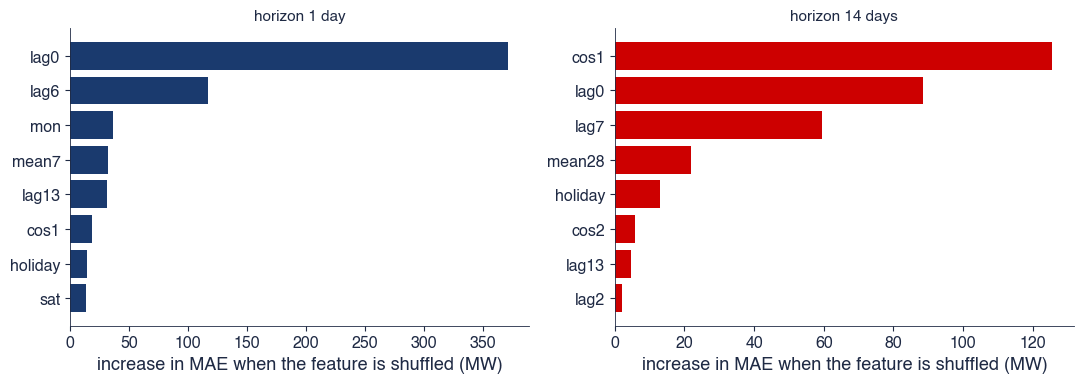

{'1': {'lag0': 0.37081318964976917, 'lag6': 0.1169469369711342, 'mon': 0.03642649322218454, 'mean7': 0.03189960442069569, 'lag13': 0.031407034033715656, 'cos1': 0.018734206929261404}, '14': {'cos1': 0.1255691690037411, 'lag0': 0.0885873807797459, 'lag7': 0.05948657884507087, 'mean28': 0.02201492395496825, 'holiday': 0.012928459113421355, 'cos2': 0.005840451282395201}}


{'level': 0.9, 'n': 182, 'n_cal': 182, 'quantile': {'cover': 0.6758241758241759, 'width': 0.8960705502536235, 'below': 0.1978021978021978, 'above': 0.12637362637362637}, 'conformal': {'cover': 0.9120879120879121, 'width': 1.3094320788945282, 'below': 0.04945054945054945, 'above': 0.038461538461538464}}


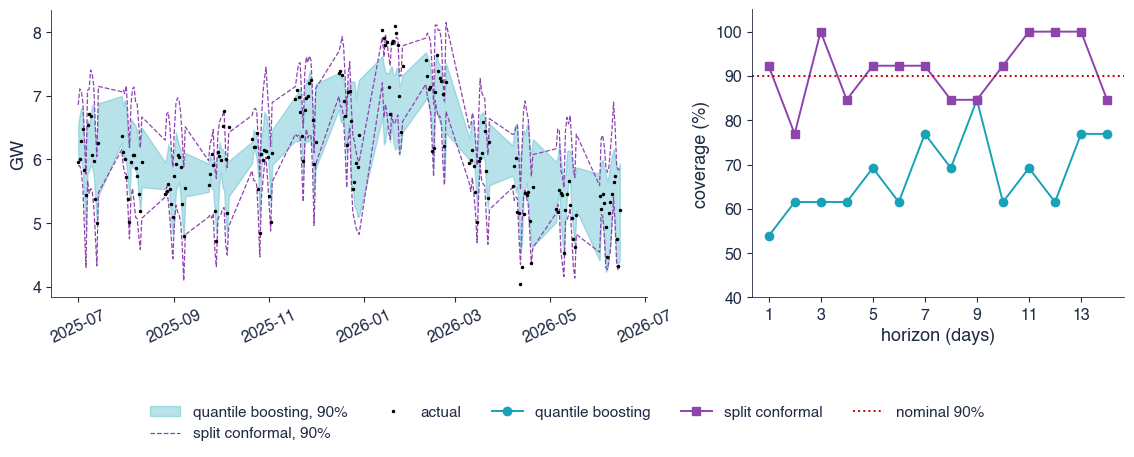

In [13]:
def importance(y=None, end=CV_FIRST, seed=SEED):
    """Permutation importance (increase in MAE) of the gradient-boosting model for h = 1 and h = 14, trained up to
    31 December 2024 and evaluated on 1 January - 30 June 2025."""
    y = load_daily() if y is None else y
    out = {}
    for h in (1, 14):
        F = direct_frame(y.loc[:end], h).dropna()
        tr = F.loc[:pd.Timestamp('2024-12-31') - pd.Timedelta(days=h)]
        te = F.loc['2025-01-01':]
        m = make_gb(seed).fit(tr[FEATS], tr['y'])
        pi = permutation_importance(m, te[FEATS], te['y'], n_repeats=20, random_state=seed,
                                    scoring='neg_mean_absolute_error')
        out[h] = pd.Series(pi.importances_mean, index=FEATS).sort_values(ascending=False)
    return out


def fig_importance(I=None, save=True):
    I = I or importance()
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.0))
    for a, h, col in [(ax[0], 1, st.MainBlue), (ax[1], 14, st.IDAred)]:
        s = 1000 * I[h].iloc[:8][::-1]
        a.barh(s.index, s.values, color=col)
        a.set_title(f'horizon {h} day' + ('s' if h > 1 else ''), fontsize=11)
        a.set_xlabel('increase in MAE when the feature is shuffled (MW)')
    fig.tight_layout()
    st.check_no_grey(fig)
    if save:
        st.save_fig('tsa_ch9_importance')
    else:
        plt.show()
    return {str(h): {k: float(v) for k, v in I[h].iloc[:6].items()} for h in I}


def load_intervals(y=None, level=0.9, n_cal=182, seed=SEED, every=1):
    """90% intervals for the direct gradient-boosting forecasts on the 26 origins:
    (1) quantile boosting (pinball loss at 5% and 95%); (2) split conformal: the model is trained without the last
    182 origins, whose absolute h-step errors give the half-width (the ceil((n+1) 0.9)-th smallest)."""
    y = load_daily() if y is None else y
    frames = {h: direct_frame(y, h) for h in range(1, CV_H + 1)}
    lo_q, hi_q = (1 - level) / 2, (1 + level) / 2
    rows = []
    for o in origins(y)[::every]:
        for h in range(1, CV_H + 1):
            F = frames[h]
            tr = F.loc[:o - pd.Timedelta(days=h)].dropna()
            x0 = F.loc[[o], FEATS].values
            act = float(y.get(o + pd.Timedelta(days=h), np.nan))
            point = make_gb(seed).fit(tr[FEATS].values, tr['y'].values).predict(x0)[0]
            ql = make_gb(seed, loss='quantile', quantile=lo_q).fit(tr[FEATS].values, tr['y'].values).predict(x0)[0]
            qh = make_gb(seed, loss='quantile', quantile=hi_q).fit(tr[FEATS].values, tr['y'].values).predict(x0)[0]
            fit, cal = tr.iloc[:-n_cal], tr.iloc[-n_cal:]
            mc = make_gb(seed).fit(fit[FEATS].values, fit['y'].values)
            res = np.sort(np.abs(cal['y'].values - mc.predict(cal[FEATS].values)))
            k = int(np.ceil((n_cal + 1) * level)) - 1
            q = res[min(k, n_cal - 1)]
            pc = mc.predict(x0)[0]
            rows.append({'origin': o, 'h': h, 'date': o + pd.Timedelta(days=h), 'actual': act, 'point': point,
                         'q_lo': ql, 'q_hi': qh, 'c_point': pc, 'c_lo': pc - q, 'c_hi': pc + q})
    R = pd.DataFrame(rows)
    out = {'level': level, 'n': int(len(R)), 'n_cal': n_cal}
    for k, (a, b) in {'quantile': ('q_lo', 'q_hi'), 'conformal': ('c_lo', 'c_hi')}.items():
        inside = (R['actual'] >= R[a]) & (R['actual'] <= R[b])
        out[k] = {'cover': float(inside.mean()), 'width': float((R[b] - R[a]).mean()),
                  'below': float((R['actual'] < R[a]).mean()), 'above': float((R['actual'] > R[b]).mean())}
    return R, out


def fig_intervals(R, out, y=None, save=True):
    """The h-step-ahead forecasts at horizon 1 day (all origins joined): actual load and the two 90% intervals."""
    y = load_daily() if y is None else y
    fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.0), gridspec_kw={'width_ratios': [1.6, 1]})
    r = R.sort_values('date')
    ax[0].fill_between(r['date'], r['q_lo'], r['q_hi'], color=st.Teal, alpha=0.3, label='quantile boosting, 90%')
    ax[0].plot(r['date'], r['c_lo'], color=st.Purple, lw=0.9, ls='--', label='split conformal, 90%')
    ax[0].plot(r['date'], r['c_hi'], color=st.Purple, lw=0.9, ls='--', label='_nolegend_')
    ax[0].plot(r['date'], r['actual'], color='black', lw=0, marker='.', ms=3, label='actual')
    ax[0].set_ylabel('GW')
    ax[0].tick_params(axis='x', labelrotation=25)
    cov = R.assign(qi=(R['actual'] >= R['q_lo']) & (R['actual'] <= R['q_hi']),
                   ci=(R['actual'] >= R['c_lo']) & (R['actual'] <= R['c_hi'])).groupby('h')[['qi', 'ci']].mean()
    ax[1].plot(cov.index, 100 * cov['qi'], color=st.Teal, marker='o', label='quantile boosting')
    ax[1].plot(cov.index, 100 * cov['ci'], color=st.Purple, marker='s', label='split conformal')
    ax[1].axhline(90, color=st.IDAred, ls=':', label='nominal 90%')
    ax[1].set_xlabel('horizon (days)')
    ax[1].set_xticks(range(1, CV_H + 1, 2))
    ax[1].set_ylabel('coverage (%)')
    ax[1].set_ylim(40, 105)
    st.fig_legend_bottom(fig, ncol=5, y=0.0)
    fig.tight_layout(rect=(0, 0.07, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('tsa_ch9_intervals')
    else:
        plt.show()


print(fig_importance(save=False))
R, out = load_intervals(y, every=2)
print(out)
fig_intervals(R, out, y, save=False)

## 8. Romanian inflation: local and global models

- 27 EU countries from Eurostat; yearly walk-forward from 2016; horizons 1, 3, 6, 12 months.

              1      3      6      12
AR         0.904  0.902  0.902  1.098
GB global  1.014  0.970  1.052  1.166
GB local   1.112  1.157  1.052  1.213
Lasso      1.013  1.023  1.005  1.051
RF         1.017  1.055  1.036  1.092
RW         1.000  1.000  1.000  1.000


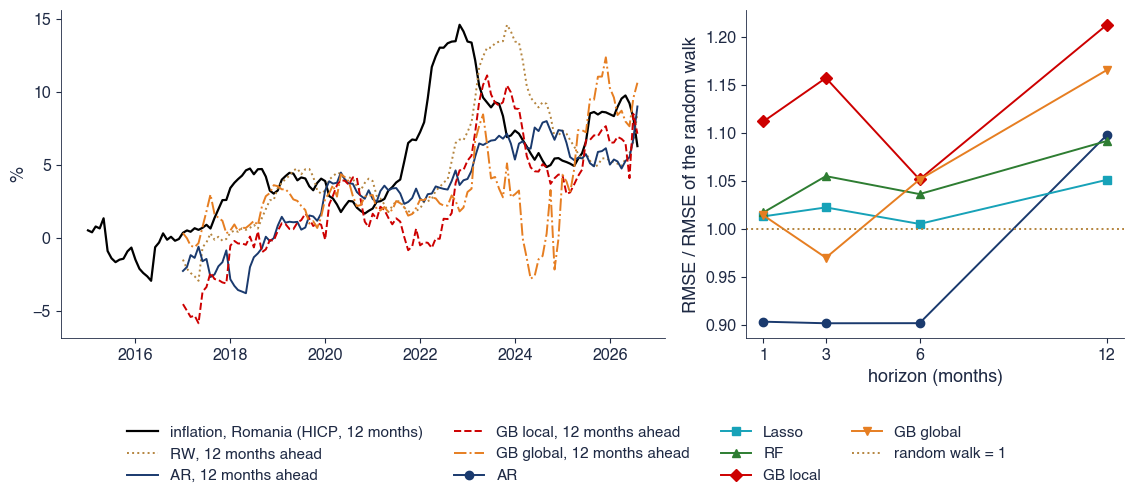

{'max': 14.591620820990258, 'max_d': '2022-11-01', 'last': 6.2741253599656766, 'last_d': '2026-08-01', 'min': -2.9558578839189553, 'min_d': '2016-05-01'}


In [14]:
def inflation_panel(countries=EU27, start=INF_START):
    """12-month HICP inflation (%) of the EU countries, monthly: pi_t = 100 (P_t / P_{t-12} - 1)."""
    P = pd.concat([hicp(g) for g in countries], axis=1)
    return (100 * (P / P.shift(12) - 1)).loc[start:]


def inflation_frame(pi, P, h):
    """Features at month t for one country: pi_t, pi_{t-1}, pi_{t-2}, pi_{t-3}, pi_{t-6}, pi_{t-12}, the monthly log
    changes m_t, m_{t-1}, m_{t-2} and their 3- and 6-month sums, the calendar month of t; target: the change
    pi_{t+h} - pi_t (trees then never need to extrapolate the level)."""
    m = 100 * np.log(P).diff()
    X = pd.DataFrame({'pi0': pi, 'pi1': pi.shift(1), 'pi2': pi.shift(2), 'pi3': pi.shift(3), 'pi6': pi.shift(6),
                      'pi12': pi.shift(12), 'm0': m, 'm1': m.shift(1), 'm2': m.shift(2), 'm3s': m.rolling(3).sum(),
                      'm6s': m.rolling(6).sum()})
    X['month'] = X.index.month
    X['y'] = pi.shift(-h) - pi
    X['target_date'] = pd.Series(X.index, index=X.index).shift(-h)
    return X


def inflation_models(seed=SEED):
    return {'AR': ('local', lambda: LinearRegression()),
            'Lasso': ('local', lambda: make_pipeline(StandardScaler(), LassoCV(cv=TimeSeriesSplit(5), n_alphas=30))),
            'RF': ('local', lambda: RandomForestRegressor(300, min_samples_leaf=5, max_features=0.5, n_jobs=-1,
                                                          random_state=seed)),
            'GB local': ('local', lambda: make_gb(seed, max_iter=200, min_samples_leaf=10)),
            'GB global': ('global', lambda: make_gb(seed, max_iter=300, min_samples_leaf=20))}


def inflation_forecasts(geo='RO', H=INF_H, oos=INF_OOS, seed=SEED, save=True):
    """Yearly walk-forward: in January of each test year the models are refitted on all rows whose target month is
    already observed (expanding window from 2006); forecasts of pi_{t+h} for every origin t of that year.
    Local models: Romania only; the global model: the 27 EU countries pooled."""
    pi = inflation_panel()
    P = pd.concat([hicp(g) for g in EU27], axis=1).loc[INF_START:]
    rows = []
    models = inflation_models(seed)
    for h in H:
        frames = {g: inflation_frame(pi[g], P[g], h).loc['2006-01-01':] for g in EU27}
        Fr = frames[geo]
        last_obs = pi[geo].dropna().index[-1]
        years = range(oos, last_obs.year + 1)
        for yr in years:
            o0 = pd.Timestamp(f'{yr}-01-01')
            te = Fr.loc[(Fr.index >= o0) & (Fr.index < pd.Timestamp(f'{yr + 1}-01-01'))].dropna(subset=INF_FEATS)
            te = te[te['target_date'] <= last_obs]
            if te.empty:
                continue
            avail = o0 - pd.offsets.MonthBegin(1)          # last month observed at the January refit
            def train(g):
                f = frames[g].dropna()
                return f[f['target_date'] <= avail]
            trl = train(geo)
            trg = pd.concat([train(g) for g in EU27])
            pred = {'RW': np.zeros(len(te))}
            for name, (kind, make) in models.items():
                tr = trl if kind == 'local' else trg
                pred[name] = make().fit(tr[INF_FEATS].values, tr['y'].values).predict(te[INF_FEATS].values)
            for i, (t, r) in enumerate(te.iterrows()):
                for name, v in pred.items():
                    rows.append({'h': h, 'origin': t, 'target': r['target_date'], 'model': name,
                                 'actual': r['pi0'] + r['y'], 'fc': r['pi0'] + v[i]})
    E = pd.DataFrame(rows)
    E['err'] = E['actual'] - E['fc']
    if save:
        E.round(5).to_csv(os.path.join(HERE, 'ch9_inflation.csv'), index=False)
    return E, pi


def inflation_summary(E):
    """RMSE by model and horizon; relative RMSE against the random walk; DM tests (squared errors, HAC with h - 1
    lags) of every model against the random walk and of the global against the local boosting."""
    out = {}
    for h, g in E.groupby('h'):
        piv = g.pivot(index='origin', columns='model', values='err')
        rm = np.sqrt((piv ** 2).mean())
        out[int(h)] = {'rmse': rm.to_dict(), 'rel': (rm / rm['RW']).to_dict(), 'n': int(len(piv)),
                       'first': str(piv.index[0].date()), 'last': str(piv.index[-1].date()),
                       'dm_rw': {m: dm_raw(piv[m] ** 2, piv['RW'] ** 2, h=int(h)) for m in piv if m != 'RW'},
                       'dm_gl': dm_raw(piv['GB global'] ** 2, piv['GB local'] ** 2, h=int(h)),
                       'dm_ar': {m: dm_raw(piv[m] ** 2, piv['AR'] ** 2, h=int(h)) for m in piv if m not in ('AR',)}}
        sub = piv.loc['2021-01-01':'2023-12-31']
        out[int(h)]['rmse_2123'] = np.sqrt((sub ** 2).mean()).to_dict()
        sub = piv.loc[:'2020-12-31']
        out[int(h)]['rmse_1620'] = np.sqrt((sub ** 2).mean()).to_dict()
    return out


def fig_inflation(E, pi, S, save=True):
    """Left: Romanian inflation and the 12-month-ahead forecasts (plotted at the target month) of the random walk,
    the AR model and the local and global boosting; right: RMSE relative to the random walk by horizon."""
    fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2), gridspec_kw={'width_ratios': [1.6, 1]})
    s = pi['RO'].loc['2015-01-01':]
    ax[0].plot(s.index, s.values, color='black', lw=1.6, label='inflation, Romania (HICP, 12 months)')
    g = E[E['h'] == 12]
    for m, ls in [('RW', ':'), ('AR', '-'), ('GB local', '--'), ('GB global', '-.')]:
        e = g[g['model'] == m].sort_values('target')
        ax[0].plot(e['target'], e['fc'], color=MCOL[m], lw=1.4, ls=ls, label=f'{m}, 12 months ahead')
    ax[0].set_ylabel('%')
    for m, mk in [('AR', 'o'), ('Lasso', 's'), ('RF', '^'), ('GB local', 'D'), ('GB global', 'v')]:
        ax[1].plot(INF_H, [S[h]['rel'][m] for h in INF_H], marker=mk, color=MCOL[m], label=m)
    ax[1].axhline(1, color=MCOL['RW'], ls=':', label='random walk = 1')
    ax[1].set_xticks(INF_H)
    ax[1].set_xlabel('horizon (months)')
    ax[1].set_ylabel('RMSE / RMSE of the random walk')
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    fig.tight_layout(rect=(0, 0.02, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('tsa_ch9_inflation')
    else:
        plt.show()
    return {'max': float(s.max()), 'max_d': str(s.idxmax().date()), 'last': float(s.dropna().iloc[-1]),
            'last_d': str(s.dropna().index[-1].date()), 'min': float(s.min()), 'min_d': str(s.idxmin().date())}


E, pi = inflation_forecasts(save=False)
SI = inflation_summary(E)
print(pd.DataFrame({h: SI[h]['rel'] for h in SI}).round(3))
print(fig_inflation(E, pi, SI, save=False))

## 9. Realised volatility and the sign of returns

- HAR against lasso, random forest, GB and an MLP for the S&P 500 (the slides also show the DAX); the sign of the next daily return against the majority-class baseline.

       r2_mean  r2_har   qlike    dm_t    dm_p
HAR     0.6147  0.0000  0.4141     NaN     NaN
Lasso   0.6419  0.0707  0.3998 -5.1223  0.0000
RF      0.6185  0.0099  0.4158  0.3220  0.7475
GB      0.6129 -0.0046  0.4161  0.3477  0.7281
MLP     0.6468  0.0833  0.3976 -3.9628  0.0001


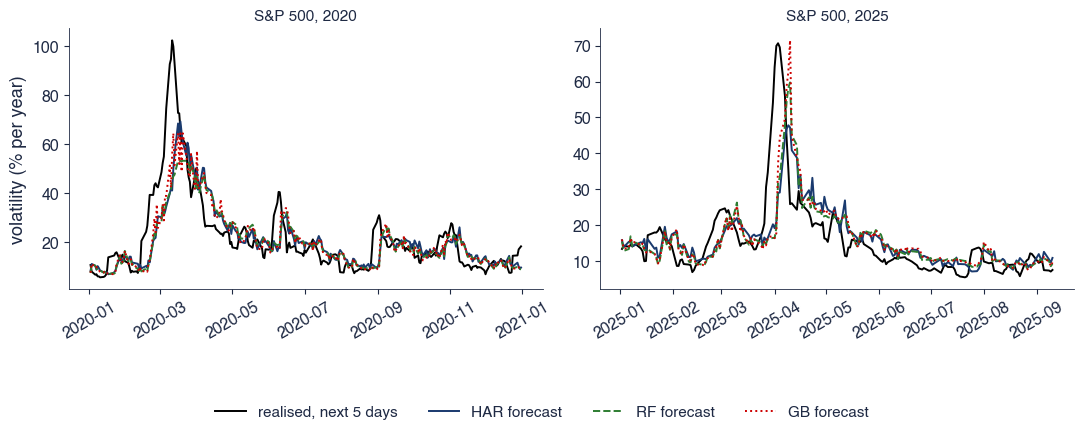

In [15]:
def daily_variance(k):
    """Daily variance proxy (%^2): overnight return squared plus the Garman-Klass (1980) term,
    v_t = o_t^2 + 0.5 (u - d)^2 - (2 ln 2 - 1) c^2, with o = ln(O_t/C_t-1), u = ln(H/O), d = ln(L/O), c = ln(C/O)."""
    t = load_ohlc(k, start=OHLC_START[k])
    t = t[(t['high'] >= t[['open', 'close']].max(axis=1)) & (t['low'] <= t[['open', 'close']].min(axis=1))]
    t = t[~((t['close'].diff() == 0) & (t['high'] == t['low']))]
    lo, lh, ll, lc = (100 * np.log(t[c]) for c in ['open', 'high', 'low', 'close'])
    o, u, d, c = lo - lc.shift(), lh - lo, ll - lo, lc - lo
    v = (o ** 2 + 0.5 * (u - d) ** 2 - (2 * np.log(2) - 1) * c ** 2).dropna()
    r = (lc - lc.shift()).dropna()
    return v.clip(lower=0.01 * v.median()), r


def rv_frame(k, h=RV_H):
    """Features at the close of day t and the target: y = log of the mean variance proxy over days t+1..t+h.
    HAR features: d = log v_t, w = log mean(v_t-4..v_t), m = log mean(v_t-21..v_t); extended: lags 1-4 of d,
    q = log mean over 66 days, the return r_t, its negative part and its absolute value."""
    v, r = daily_variance(k)
    X = pd.DataFrame({'d': np.log(v), 'w': np.log(v.rolling(5).mean()), 'm': np.log(v.rolling(22).mean()),
                      'q': np.log(v.rolling(66).mean())})
    for j in range(1, 5):
        X[f'd{j}'] = X['d'].shift(j)
    X['r'] = r
    X['r_neg'] = r.clip(upper=0)
    X['abs_r'] = r.abs()
    fut = sum(v.shift(-j) for j in range(1, h + 1)) / h
    X['rv'] = fut
    X['y'] = np.log(fut)
    return X.dropna()


class MeanModel:
    """Benchmark: the mean of the training target."""

    def fit(self, X, y):
        self.m = float(np.mean(y))
        return self

    def predict(self, X):
        return np.full(len(X), self.m)


class MLPEnsemble:
    """The average of five small MLPs (different random starting weights); inputs and target standardised."""

    def __init__(self, hidden=(16,), alpha=1e-2, n_models=5, epochs=200, seed=SEED):
        self.hidden, self.alpha, self.n_models, self.epochs, self.seed = hidden, alpha, n_models, epochs, seed

    def fit(self, X, y):
        self.sx = StandardScaler().fit(X)
        self.my, self.sy = float(np.mean(y)), float(np.std(y))
        Z, t = self.sx.transform(X), (np.asarray(y) - self.my) / self.sy
        self.models = [MLPRegressor(hidden_layer_sizes=self.hidden, alpha=self.alpha, max_iter=self.epochs,
                                    random_state=self.seed + i).fit(Z, t) for i in range(self.n_models)]
        return self

    def predict(self, X):
        Z = self.sx.transform(X)
        return self.my + self.sy * np.mean([m.predict(Z) for m in self.models], axis=0)


def rv_models(seed=SEED):
    return {'Mean': (HAR, lambda: MeanModel()),
            'HAR': (HAR, lambda: LinearRegression()),
            'Lasso': (EXT, lambda: make_pipeline(StandardScaler(), LassoCV(cv=TimeSeriesSplit(5, gap=RV_H), n_alphas=40))),
            'RF': (EXT, lambda: RandomForestRegressor(n_estimators=300, min_samples_leaf=20, max_features=0.5,
                                                      n_jobs=-1, random_state=seed)),
            'GB': (EXT, lambda: make_gb(seed, max_iter=300, learning_rate=0.03, max_leaf_nodes=8, min_samples_leaf=50)),
            'MLP': (EXT, lambda: MLPEnsemble(seed=seed))}


def walk_forward(X, feats, make_model, oos_start, h=RV_H, target='y'):
    """Yearly refits on an expanding window: for each test year, train on all earlier rows except the last h, whose
    targets overlap the test year (the gap), then forecast every row of the year."""
    years = sorted(set(X.index[X.index >= oos_start].year))
    pred, s2 = pd.Series(np.nan, index=X.index), pd.Series(np.nan, index=X.index)
    for yr in years:
        te = X.index.year == yr
        tr = X[X.index < f'{yr}-01-01']
        tr = tr.iloc[:-h] if h > 0 else tr
        m = make_model().fit(tr[feats].values, tr[target].values)
        pred[te] = m.predict(X.loc[te, feats].values)
        s2[te] = float(np.var(tr[target].values - m.predict(tr[feats].values)))
    keep = X.index >= oos_start
    return pd.DataFrame({'pred': pred[keep], 's2': s2[keep]})


def qlike(rv, h):
    """QLIKE loss of Chapter 5: L = RV / h + ln h (lower is better)."""
    return rv / h + np.log(h)


def dm_hac(d, lag=RV_H):
    """Diebold-Mariano statistic for the mean of a loss difference d_t, Newey-West (Bartlett) long-run variance with
    `lag` lags; two-sided p-value from N(0, 1)."""
    d = np.asarray(d, float)
    n, u = len(d), d - d.mean()
    lrv = np.sum(u * u) / n
    for j in range(1, lag + 1):
        lrv += 2 * (1 - j / (lag + 1)) * np.sum(u[j:] * u[:-j]) / n
    t = d.mean() / np.sqrt(lrv / n)
    return float(t), float(2 * stats.norm.sf(abs(t)))


def rv_forecasts(k, models=None, h=RV_H):
    X = rv_frame(k, h)
    models = models or rv_models()
    P = {}
    for name, (feats, make) in models.items():
        f = walk_forward(X, feats, make, RV_OOS[k], h)
        f['var'] = np.exp(f['pred'] + f['s2'] / 2)
        P[name] = f
    return X, P


def rv_metrics(X, P, bench='HAR', h=RV_H):
    idx = P[bench].index
    y, rv = X.loc[idx, 'y'], X.loc[idx, 'rv']
    out = {}
    for name, f in P.items():
        L = qlike(rv, f['var'])
        Lb = qlike(rv, P[bench]['var'])
        t, p = dm_hac(L - Lb, h) if name != bench else (np.nan, np.nan)
        out[name] = {'r2_mean': oos_r2(y, f['pred'], P['Mean']['pred']), 'r2_har': oos_r2(y, f['pred'], P[bench]['pred']),
                     'qlike': float(L.mean()), 'dm_t': t, 'dm_p': p}
    out['n'] = int(len(idx))
    out['first'] = str(idx[0].date())
    out['last'] = str(idx[-1].date())
    return out


def fig_rv(X, P, k='sp500', periods=(('2020-01-01', '2020-12-31'), ('2025-01-01', '2025-09-10')), save=True):
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.0))
    for i, (s, e) in enumerate(periods):
        idx = P['HAR'].loc[s:e].index
        ax[i].plot(idx, np.sqrt(252 * X.loc[idx, 'rv']), color='black', lw=1.4, label='realised, next 5 days')
        for name, ls in [('HAR', '-'), ('RF', '--'), ('GB', ':')]:
            ax[i].plot(idx, np.sqrt(252 * P[name].loc[idx, 'var']), color=MCOL[name], lw=1.4, ls=ls,
                       label=f'{name} forecast')
        ax[i].set_title(f'{NAME[k]}, {s[:4]}', fontsize=11)
        ax[i].tick_params(axis='x', labelrotation=30)
    ax[0].set_ylabel('volatility (% per year)')
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('tsa_ch9_rv')
    else:
        plt.show()


X, P = rv_forecasts('sp500')
M = rv_metrics(X, P)
print(pd.DataFrame({m: M[m] for m in ['HAR', 'Lasso', 'RF', 'GB', 'MLP']}).T.round(4))
fig_rv(X, P, save=False)

{'sp500': (0.5441, {'Logit': 0.5379, 'RF': 0.5311, 'GB': 0.525}), 'bet': (0.5378, {'Logit': 0.5373, 'RF': 0.5363, 'GB': 0.522})}


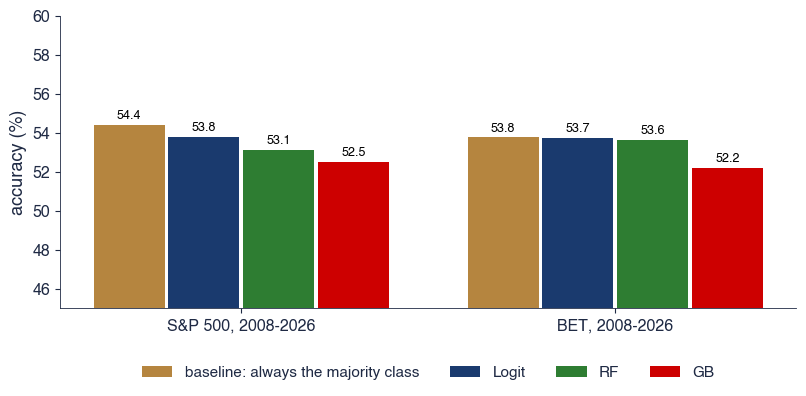

In [16]:
def sign_frame(k):
    """Features at the close of day t (the last five returns, sums over 5, 21 and 63 days, volatility over 21 and 63
    days) and the target 1{r_t+1 > 0}."""
    r = log_returns(k, '2000-01-01')
    X = pd.DataFrame({f'r{j}': r.shift(j) for j in range(5)})
    X['m5'], X['m21'], X['m63'] = r.rolling(5).sum(), r.rolling(21).sum(), r.rolling(63).sum()
    X['v21'], X['v63'] = r.rolling(21).std(), r.rolling(63).std()
    X['y'] = (r.shift(-1) > 0).astype(float)
    X['ret'] = r.shift(-1)
    return X.dropna()


def sign_models(seed=SEED):
    return {'Logit': lambda: make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=1000)),
            'RF': lambda: RandomForestClassifier(n_estimators=300, min_samples_leaf=100, max_features=0.5, n_jobs=-1,
                                                 random_state=seed),
            'GB': lambda: HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05, max_depth=2,
                                                         min_samples_leaf=100, random_state=seed)}


def sign_walk_forward(k, models=None, oos_start='2008-01-01'):
    """Yearly walk-forward classification; the majority class of the training sample is the baseline forecast."""
    X = sign_frame(k)
    models = models or sign_models()
    keep = X.index >= oos_start
    prob = {m: pd.Series(np.nan, index=X.index) for m in models}
    base = pd.Series(np.nan, index=X.index)
    for yr in sorted(set(X.index[keep].year)):
        te = X.index.year == yr
        tr = X[X.index < f'{yr}-01-01'].iloc[:-1]
        base[te] = float(tr['y'].mean() >= 0.5)
        for name, make in models.items():
            m = make().fit(tr[SIGN_FEATS].values, tr['y'].astype(int).values)
            prob[name][te] = m.predict_proba(X.loc[te, SIGN_FEATS].values)[:, 1]
    return X[keep], {m: p[keep] for m, p in prob.items()}, base[keep]


def sign_metrics(X, prob, base):
    """Accuracy of each model and of the baseline; z test of the accuracy against the baseline rate; AUC."""
    y = X['y'].values
    acc_b = float(np.mean(base.values == y))
    n = len(y)
    out = {'n': int(n), 'up': float(y.mean()), 'base_acc': acc_b, 'first': str(X.index[0].date())}
    for name, p in prob.items():
        acc = float(np.mean((p.values >= 0.5) == y))
        z = (acc - acc_b) / np.sqrt(acc_b * (1 - acc_b) / n)
        out[name] = {'acc': acc, 'diff': acc - acc_b, 'z': float(z), 'p': float(2 * stats.norm.sf(abs(z))),
                     'auc': float(roc_auc_score(y, p.values)), 'share_up_pred': float(np.mean(p.values >= 0.5))}
    return out


def fig_sign(S, save=True):
    fig, ax = plt.subplots(figsize=(9.5, 3.8))
    ks = list(S)
    xs = np.arange(len(ks))
    for i, (m, col) in enumerate([('base', st.Amber), ('Logit', st.MainBlue), ('RF', st.Forest), ('GB', st.IDAred)]):
        vals = [100 * (S[k]['base_acc'] if m == 'base' else S[k][m]['acc']) for k in ks]
        b = ax.bar(xs + (i - 1.5) * 0.2, vals, width=0.19, color=col,
                   label='baseline: always the majority class' if m == 'base' else m)
        for rect, v in zip(b, vals):
            ax.text(rect.get_x() + rect.get_width() / 2, v + 0.3, f'{v:.1f}', ha='center', fontsize=9, color='black')
    ax.set_xticks(xs)
    ax.set_xticklabels([f'{NAME[k]}, {S[k]["first"][:4]}-2026' for k in ks])
    ax.set_ylim(45, 60)
    ax.set_ylabel('accuracy (%)')
    st.legend_outside_bottom(ax, ncol=4, y=-0.15)
    st.check_no_grey(fig)
    if save:
        st.save_fig('tsa_ch9_sign')
    else:
        plt.show()


SG = {k: sign_metrics(*sign_walk_forward(k)) for k in ('sp500', 'bet')}
print({k: (round(v['base_acc'], 4), {m: round(v[m]['acc'], 4) for m in ('Logit', 'RF', 'GB')}) for k, v in SG.items()})
fig_sign(SG, save=False)

## 10. Case studies: M4 and Gu, Kelly and Xiu (2020)

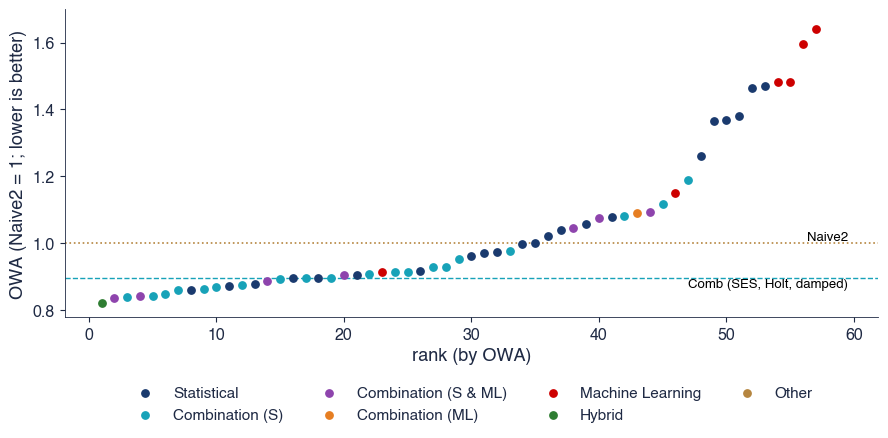

{'n': 59, 'comb': 0.8976361303983924, 'best': '118', 'best_owa': 0.8208548754209313, 'best_smape': 11.374402, 'second_owa': 0.8377020377296039, 'n_ml': 6, 'ml_best_owa': 0.9150450172025496, 'ml_best_rank': 23, 'ml_beat_naive2': 1, 'ml_beat_comb': 0, 'naive2_smape': 13.56407, 'comb_smape': 12.55471, 'top17_comb': 12, 'n_off': 2}


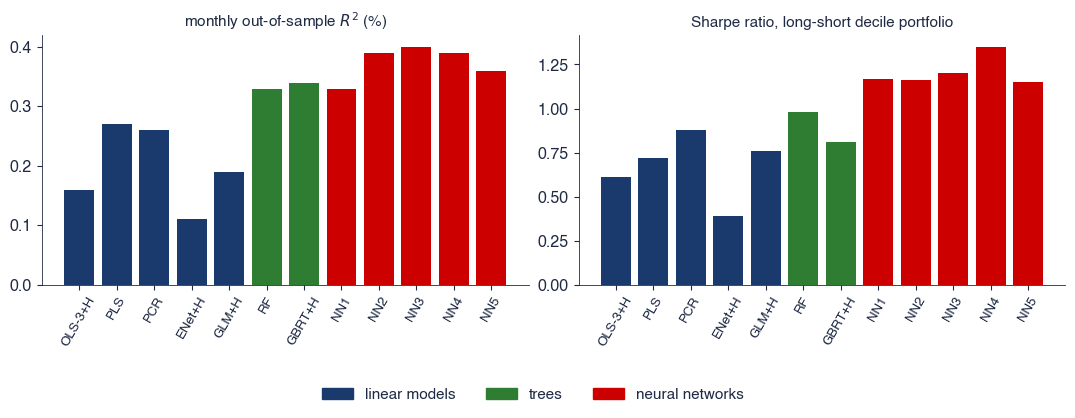

In [17]:
def m4_table():
    """OWA, sMAPE and MASE of the ranked M4 methods (extract of the official evaluation file)."""
    return pd.read_csv(ch9_file(M4_FILE))


def fig_m4(save=True):
    """OWA of the 61 methods of M4 (submitted and benchmarks), ranked, coloured by type (official evaluation file)."""
    M = m4_table().sort_values('owa').reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(10.5, 4.0))
    for t, col in M4_TYPES.items():
        s = M[M['type'] == t]
        ax.scatter(s.index + 1, s['owa'], color=col, s=28, label=t, zorder=3)
    ax.axhline(1, color=st.Amber, ls=':', lw=1.2, label='_nolegend_')
    comb = float(M.loc[M['method'] == 'Comb', 'owa'].iloc[0])
    ax.axhline(comb, color=st.Teal, ls='--', lw=1.0, label='_nolegend_')
    ax.text(len(M) + 0.5, 1.0, 'Naive2', va='bottom', ha='right', fontsize=9.5, color='black')
    ax.text(len(M) + 0.5, comb, 'Comb (SES, Holt, damped)', va='top', ha='right', fontsize=9.5, color='black')
    ax.set_ylim(0.78, 1.7)
    ax.set_xlabel('rank (by OWA)')
    ax.set_ylabel('OWA (Naive2 = 1; lower is better)')
    st.legend_outside_bottom(ax, ncol=4, y=-0.18)
    st.check_no_grey(fig)
    if save:
        st.save_fig('tsa_ch9_m4')
    else:
        plt.show()
    ml = M[M['type'] == 'Machine Learning']
    best = M.iloc[0]
    return {'n': int(len(M)), 'comb': comb, 'best': best['method'], 'best_owa': float(best['owa']),
            'best_smape': float(best['smape']), 'second_owa': float(M.iloc[1]['owa']),
            'n_ml': int(len(ml)), 'ml_best_owa': float(ml['owa'].min()), 'ml_best_rank': int(ml.index.min() + 1),
            'ml_beat_naive2': int((ml['owa'] < 1).sum()), 'ml_beat_comb': int((ml['owa'] < comb).sum()),
            'naive2_smape': float(M.loc[M['method'] == 'Naive2', 'smape'].iloc[0]),
            'comb_smape': float(M.loc[M['method'] == 'Comb', 'smape'].iloc[0]),
            'top17_comb': int(M.iloc[:17]['type'].str.startswith('Combination').sum()),
            'n_off': int((M['owa'] > 1.7).sum())}


def fig_gkx(save=True):
    """Gu, Kelly and Xiu (2020): monthly out-of-sample R^2 (Table 1, all stocks) and the annualised Sharpe ratio of
    the value-weighted long-short decile portfolio (Table 7), published numbers."""
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.9))
    x = np.arange(len(GKX_MODELS))
    cols = [st.MainBlue] * 5 + [st.Forest, st.Forest] + [st.IDAred] * 5
    ax[0].bar(x, GKX_R2, color=cols)
    ax[1].bar(x, GKX_SR, color=cols)
    for a, ttl in zip(ax, ['monthly out-of-sample $R^2$ (%)', 'Sharpe ratio, long-short decile portfolio']):
        a.set_xticks(x)
        a.set_xticklabels(GKX_MODELS, rotation=60, fontsize=9.5)
        a.set_title(ttl, fontsize=11)
    hh = [Rectangle((0, 0), 1, 1, color=c) for c in (st.MainBlue, st.Forest, st.IDAred)]
    fig.legend(hh, ['linear models', 'trees', 'neural networks'], loc='upper center', bbox_to_anchor=(0.5, 0.02),
               ncol=3, frameon=False)
    fig.tight_layout(rect=(0, 0.04, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('tsa_ch9_gkx')
    else:
        plt.show()


print(fig_m4(save=False))
fig_gkx(save=False)

## Exercises

1. Add the lags 21 and 28 to `direct_frame` and repeat the ridge and GB forecasts of Section 6.
2. Train the GB models of Section 6 on the log of the load: does the MASE change?
3. Replace the global GB of Section 8 by a global ridge model: does pooling help a linear model too?